# MSR Validation — Exploratory Pass

Explores the data and code artifacts collected by the mining layer of TestMap, and
runs the structural checks that must pass before any manual validation sampling.

This notebook is diagnostic. Its job is to find weaknesses in the collected data —
missing rows, unattributed observations, impossible values — so they can be fixed
before rater hours are spent. Every number here is free: no oracle, no raters.

Scope: this validates what TestMap **recorded and attributed**, not what the
underlying tools measured. Coverage rates and mutation statuses are taken from
`dotnet test` and Stryker as given.

Protocol and sampling design: `../msr_validation_plan.md`.

## Data Preparation

TestMap writes one SQLite database per repository revision. The `analysis` package
consolidates them into per-construct frames:

Two steps. First select the population and copy the qualifying repositories into a
validation corpus:

```powershell
uv run python -m analysis msr-population `
  --total "../Replication/FilteredTestRepoCollectTests/total" `
  --data  "../Replication/FilteredTestRepoCollectTests/data" `
  --out   msr-validation-data/population `
  --copy-to "../Replication/MSRValidation/data"
```

Then consolidate that corpus into per-construct frames:

```powershell
uv run python -m analysis msr-coverage-audit `
  --population msr-validation-data/population/msr_population.csv `
  --data "../Replication/MSRValidation/data" `
  --logs "../Replication/FilteredTestRepoCollectTests" `
  --out  "../Replication/MSRValidation/audit"

uv run python -m analysis build-msr-datasets `
  --db      "../Replication/MSRValidation/data" `
  --out     "../Replication/MSRValidation" `
  --exclude "../Replication/MSRValidation/audit/no_coverage_data.csv"
```

`--db` accepts a directory (searched recursively for `analysis.db`), a glob, or an
explicit path, and may be repeated. `--limit N` reads only the first N databases,
which is the way to do a first pass over a corpus of this size.

Frames land in `<out>/frames/`. Rows are keyed by `repo_key` (`owner/repo@commit12`)
read from each database's `projects` table — member ids are per-database
autoincrement values and collide across repositories, so every join must carry it.

In [1]:
from pathlib import Path

import pandas as pd

import matplotlib.pyplot as plt

from analysis.msr_stats import (
    NUMERIC_COLUMNS,
    describe_numeric,
    iqr_table,
    summarize_checks,
    worst_repositories,
)
from analysis import msr_plots

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

FRAMES = Path("../../Replication/MSRValidation/frames")
POPULATION = Path("../msr-validation-data/population")

def load(name: str) -> pd.DataFrame:
    path = FRAMES / f"msr_{name}.csv"
    if not path.exists():
        print(f"[missing] {path} - run build-msr-datasets first")
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False)

repositories = load("repositories")
files        = load("files")
entities     = load("entities")
code_metrics = load("code_metrics")
test_smells  = load("test_smells")
coverage     = load("coverage")
mutants      = load("mutants")
mutant_operators = load("mutant_operators")
mappings     = load("mappings")
test_results = load("test_results")
checks       = load("structural_checks")

CONSTRUCT_FRAMES = {
    "entities": entities,
    "code_metrics": code_metrics,
    "test_smells": test_smells,
    "coverage": coverage,
    "mutants": mutants,
    "mappings": mappings,
}

pd.DataFrame(
    [{"frame": n, "rows": len(f), "repos": f["repo_key"].nunique() if not f.empty else 0}
     for n, f in CONSTRUCT_FRAMES.items()]
)

,frame,rows,repos
0,entities,616718,197
1,code_metrics,614784,197
2,test_smells,89084,196
3,coverage,245806,197
4,mutants,81646,115
5,mappings,158784,184


## Pipeline Outcomes And Population Selection

Not every target produced data worth validating. Targets in `failed-total.yaml`
never reported back and are counted as **timeouts**; the rest carry a pipeline
status and a failure stage.

Selection uses the per-repository validation flags, which cascade
(`Restores` >= `Builds` >= `TestsRun` >= `HasCoverage` >= `HasMutationScore`):

- **eligible_core** — restored, built, and ran tests. **346 targets.**
- **eligible_mutation** — produced a mutation score. The frame for mutants only.

`HasCoverage` is deliberately not a selection predicate: it is set from a
`coverage_reports` row existing rather than from that row holding anything, so it
admits repositories with no coverage data at all. Whether coverage actually landed
is settled against the database by `msr-coverage-audit`, which is what takes the
346 selected repositories down to the **197** carrying coverage data — the set the
frames above are built from.

In [2]:
def load_population(name: str) -> pd.DataFrame:
    path = POPULATION / f"msr_{name}.csv"
    if not path.exists():
        print(f"[missing] {path} - run msr-population first")
        return pd.DataFrame()
    return pd.read_csv(path)

population = load_population("population")
outcomes   = load_population("outcomes")
failures   = load_population("failure_reasons")
capability = load_population("capabilities")
selection  = load_population("selection")
exclusions = load_population("exclusions")

display(outcomes)
display(failures)

,outcome,targets,share
0,completed,912,0.7042
1,failed,224,0.173
2,timeout,159,0.1228


,outcome,failure_reason,targets,share_of_all,share_of_failed
0,timeout,timeout (failed manifest),159,0.1228,0.4151
1,failed,materialization: Failed,145,0.112,0.3786
2,failed,pipeline: NotSupportedException,24,0.01853,0.06266
3,failed,pipeline: NullReferenceException,18,0.0139,0.047
4,failed,pipeline: ArgumentOutOfRangeException,10,0.007722,0.02611
5,failed,materialization: WorkspaceDirty,5,0.003861,0.01305
6,failed,coordinator: UnauthorizedAccessException,4,0.003089,0.01044
7,failed,Materialized,4,0.003089,0.01044
8,failed,materialization: RepositoryUnavailable,3,0.002317,0.007833
9,failed,coordinator: IOException,2,0.001544,0.005222


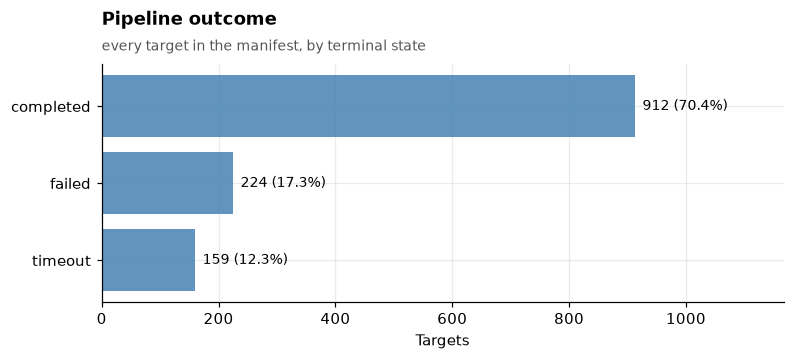

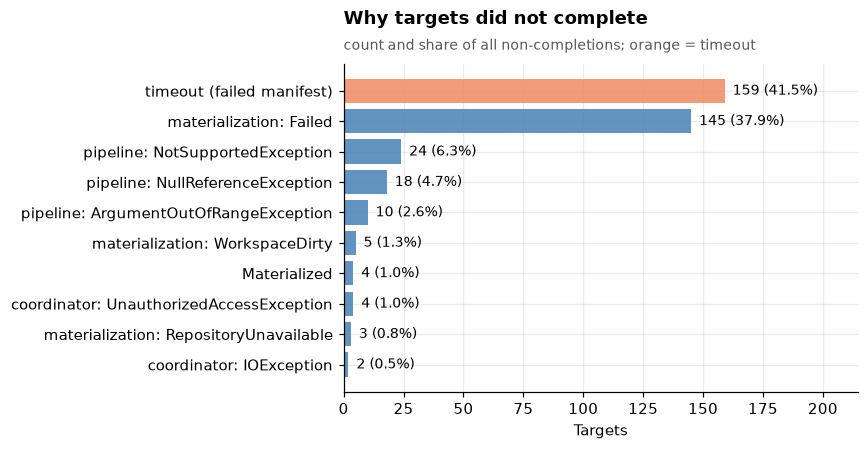

In [3]:
msr_plots.outcome_bar(outcomes)
plt.show()
msr_plots.failure_reason_bar(failures)
plt.tight_layout()
plt.show()

In [4]:
# Capability shares over completed targets: the denominator that can actually
# reach these states. Reported over all targets as well, since the manifest is
# the population a reader will assume.
display(capability)
display(selection)
display(exclusions)

,capability,repositories,denominator,share
0,Restores,346,912,0.3794
1,Builds,346,912,0.3794
2,TestsRun,346,912,0.3794
3,TestsPass,140,912,0.1535
4,HasCoverage,344,912,0.3772
5,HasMutationScore,169,912,0.1853


,population,constructs,repositories,share_of_targets
0,eligible_core,"metrics, smells, coverage, mappings",346,0.2672
1,eligible_mutation,mutants,169,0.1305
2,selected (union),copied to the validation corpus,346,0.2672
3,selected with analysis.db,actually readable,346,0.2672


,exclusion_reason,targets,share_of_all
0,failed Restores,565,0.4363
1,not completed: failed,224,0.173
2,not completed: timeout,159,0.1228
3,no validation row,1,0.0007722


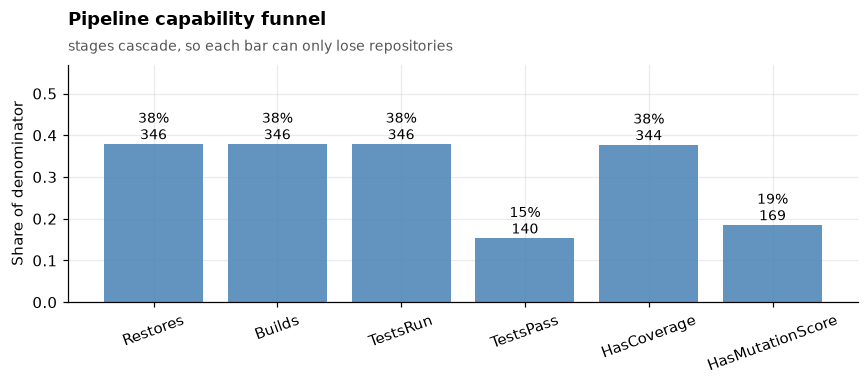

In [5]:
# Capability order is the cascade order, so the bars read as a funnel: each step
# can only lose repositories, and the size of a drop names the stage that costs most.
msr_plots.capability_funnel(capability)
plt.tight_layout()
plt.show()

## Study Population And Data Availability

Not every repository carries every construct. Static analysis runs on all of them,
but coverage and mutation only exist where the test suite built and ran, so the
denominators differ per construct. Everything downstream — sampling frames, rates,
per-construct budgets — depends on knowing these counts first.

,repositories,with_data,share
code_metrics,197,197,1
test_smells,197,196,0.9949
coverage,197,197,1
mutants,197,116,0.5888
mappings,197,184,0.934


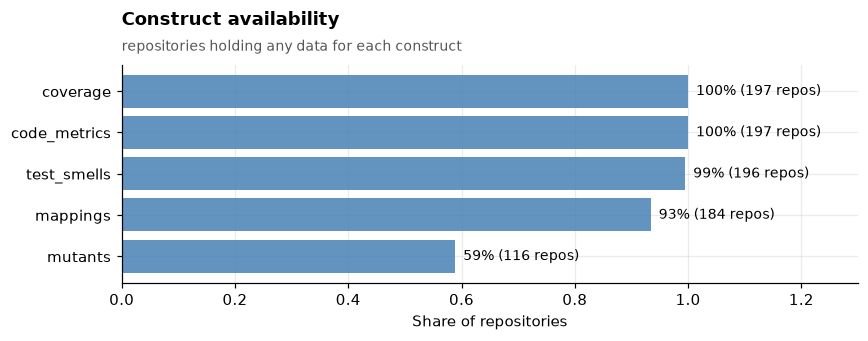

In [6]:
availability = pd.DataFrame({
    "repositories": [len(repositories)] * 5,
    "with_data": [
        int(repositories["has_metrics"].sum()),
        int(repositories["has_smells"].sum()),
        int(repositories["has_coverage"].sum()),
        int(repositories["has_mutants"].sum()),
        int(repositories["has_mappings"].sum()),
    ],
}, index=["code_metrics", "test_smells", "coverage", "mutants", "mappings"])
availability["share"] = availability["with_data"] / availability["repositories"]
display(availability)

msr_plots.availability_bar(availability)
plt.tight_layout()
plt.show()

In [7]:
# Reconcile availability against the frames themselves. A construct can be present
# in a repository yet absent from its frame when the frame's grain drops rows -
# msr_mutants is grouped per member, so a repository whose mutants are all
# unattributed produces no rows at all and disappears from it.
frame_repos = pd.DataFrame([
    {"frame": name,
     "repos_in_frame": f["repo_key"].nunique() if not f.empty else 0,
     "repos_with_data": int(repositories[flag].sum())}
    for name, f, flag in [
        ("code_metrics", code_metrics, "has_metrics"),
        ("test_smells", test_smells, "has_smells"),
        ("coverage", coverage, "has_coverage"),
        ("mutants (per member)", mutants, "has_mutants"),
        ("mutant_operators", mutant_operators, "has_mutants"),
        ("mappings", mappings, "has_mappings"),
        ("test_results", test_results, "has_test_results"),
    ]
]).assign(gap=lambda d: d["repos_with_data"] - d["repos_in_frame"])
display(frame_repos)

for row in frame_repos[frame_repos["gap"] > 0].itertuples():
    print(f"[gap] {row.frame}: {row.gap} repository(ies) hold data but contribute no rows")

,frame,repos_in_frame,repos_with_data,gap
0,code_metrics,197,197,0
1,test_smells,196,196,0
2,coverage,197,197,0
3,mutants (per member),115,116,1
4,mutant_operators,116,116,0
5,mappings,184,184,0
6,test_results,197,197,0


[gap] mutants (per member): 1 repository(ies) hold data but contribute no rows


In [8]:
# Repositories where static analysis produced nothing at all: these are not a
# sampling population, they are a pipeline failure to account for separately.
empty = repositories[repositories["members"] == 0]
print(f"repositories with zero members: {len(empty)} of {len(repositories)}")

size_cols = ["files", "objects", "members", "test_members", "code_metrics",
             "test_smells", "coverage_rows", "mutants", "mappings"]
repositories[size_cols].sum().to_frame("corpus_total")

repositories with zero members: 0 of 197


,corpus_total
files,60121
objects,82354
members,534364
test_members,69345
code_metrics,614784
test_smells,89084
coverage_rows,245806
mutants,672354
mappings,158784


## Structural Checks

Each check is a rate with an explicit numerator and denominator, computed per
repository and pooled here. Three severities:

- **defect** — the row cannot be correct as stored (orphan foreign key, duplicate
  attribution, value out of range, a line outside its member's span);
- **coverage_gap** — the row is absent rather than wrong (a member with no metric
  row, a mutant with no member attribution);
- **suspect** — worth a look, not necessarily wrong.

Rates pool numerators and denominators across repositories rather than averaging
per-repo rates, so a large repository counts for more than a tiny one.

A repository that never collected a construct is excluded from that construct's gap
rate — that is an availability fact, recorded above, and folding it in here would
swamp the real missing-row rate.

,construct,check,severity,repositories,repositories_affected,numerator,denominator,rate
0,mutants,mutants_containment_violation,defect,115,115,10241,572836,0.01788
1,mappings,mappings_duplicate_pair,defect,184,49,794,158784,0.005001
13,mappings,production_members_missing_mappings,coverage_gap,184,184,174931,193821,0.9025
14,mutants,members_missing_mutants,coverage_gap,116,116,211988,292704,0.7242
15,coverage,members_missing_coverage,coverage_gap,197,197,326226,534364,0.6105
16,coverage,objects_missing_coverage,coverage_gap,197,197,45313,82354,0.5502
17,mappings,test_members_missing_mappings,coverage_gap,184,158,21695,66487,0.3263
18,test_results,test_results_unattributed,coverage_gap,197,78,62991,201659,0.3124
19,mutants,mutants_unattributed,coverage_gap,116,63,99518,672354,0.148
20,test_results,test_members_missing_results,coverage_gap,197,49,4052,69345,0.05843


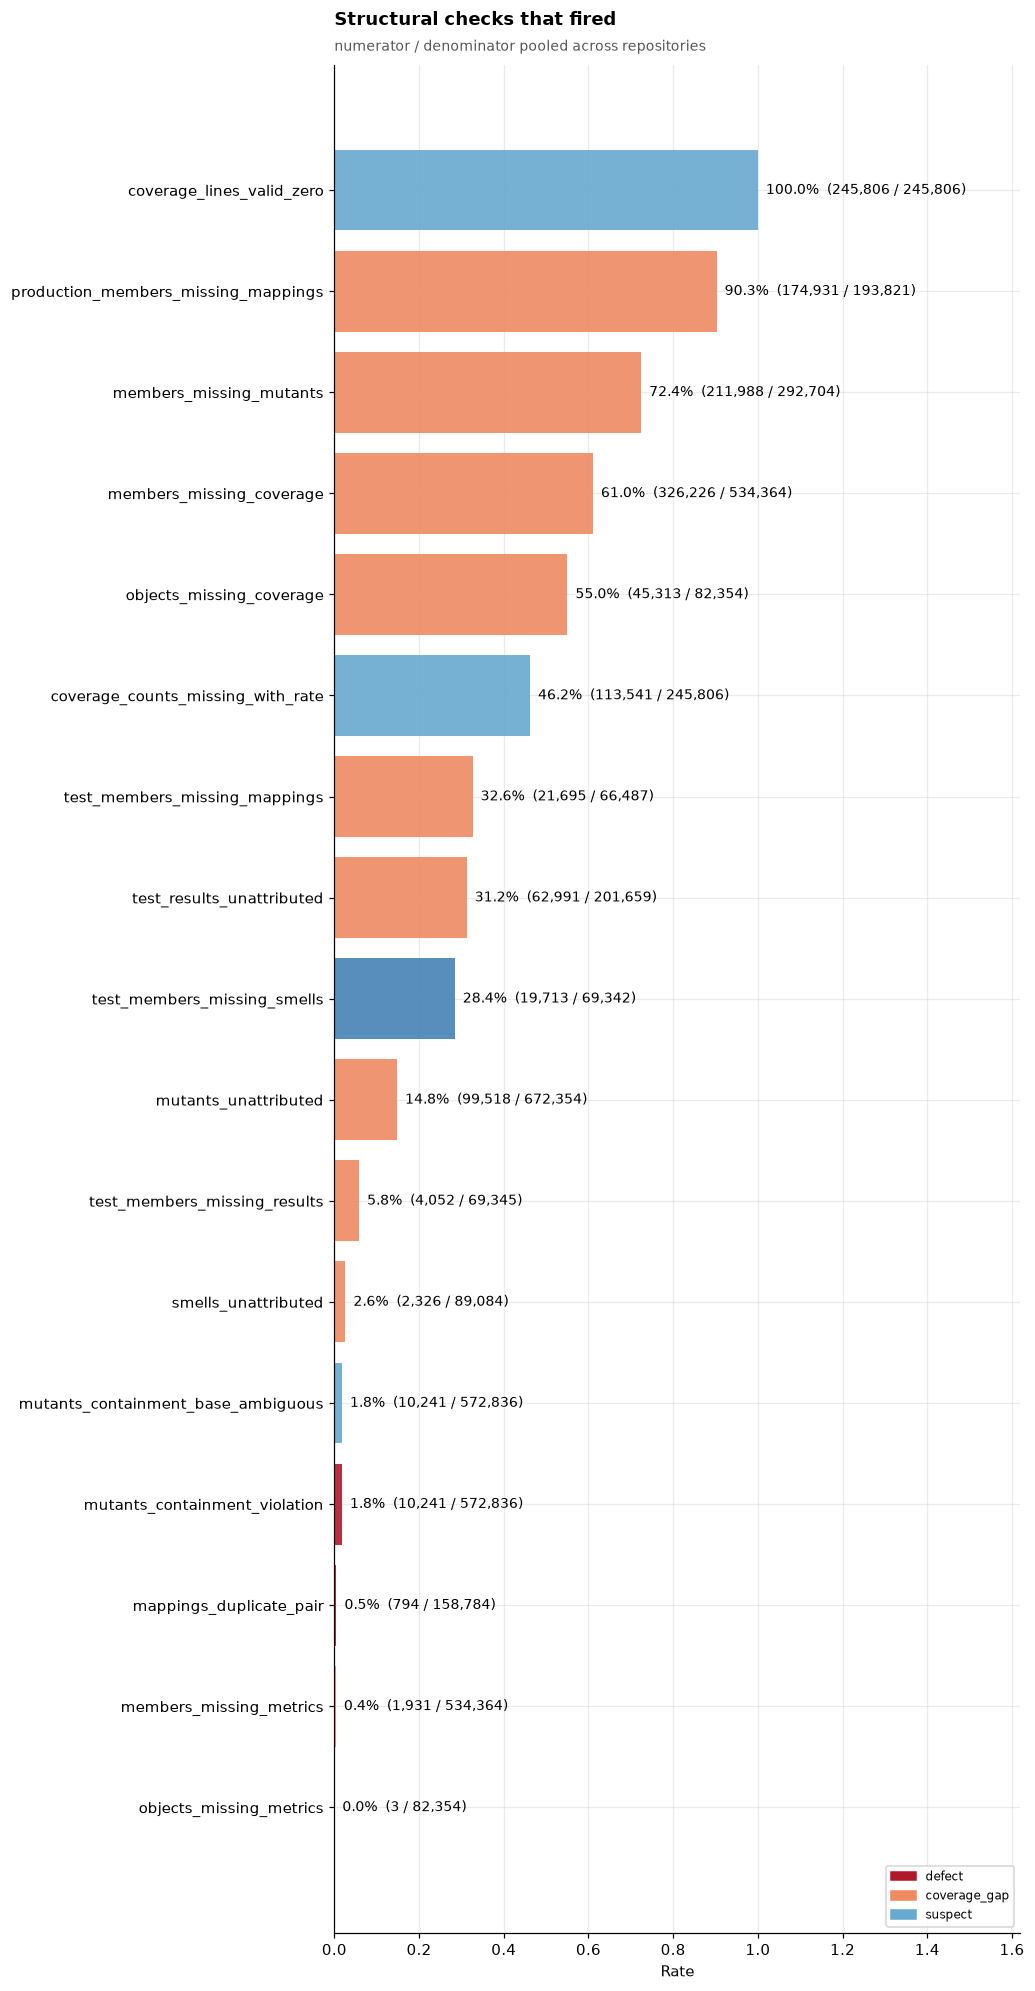

In [9]:
summary = summarize_checks(checks)
display(summary[summary["numerator"] > 0])

msr_plots.check_rate_bar(summary)
plt.tight_layout()
plt.show()

In [10]:
# Everything that came back clean. Worth reading: a check that is zero everywhere
# is either genuinely healthy or not actually exercised - confirm the denominator.
summary[summary["numerator"] == 0][["construct", "check", "denominator", "repositories"]]

,construct,check,denominator,repositories
2,code_metrics,metrics_duplicate_entity,614784,197
3,code_metrics,metrics_mi_out_of_range,614784,197
4,code_metrics,metrics_orphan_entity,614784,197
5,coverage,coverage_orphan_entity,245806,197
6,coverage,coverage_rate_out_of_range,245806,197
7,mappings,mappings_orphan_source,158784,184
8,mappings,mappings_orphan_test,158784,184
9,mappings,mappings_self_reference,158784,184
10,mutants,mutants_orphan_member,672354,116
11,test_smells,smells_containment_violation,86407,196


### Per-repository breakdown

Corpus rates hide concentration. A 3% defect rate spread evenly across every
repository is a systematic fault in the extractor; the same 3% concentrated in two
repositories is a property of those repositories. The distinction decides whether to
fix code or to stratify the sample.

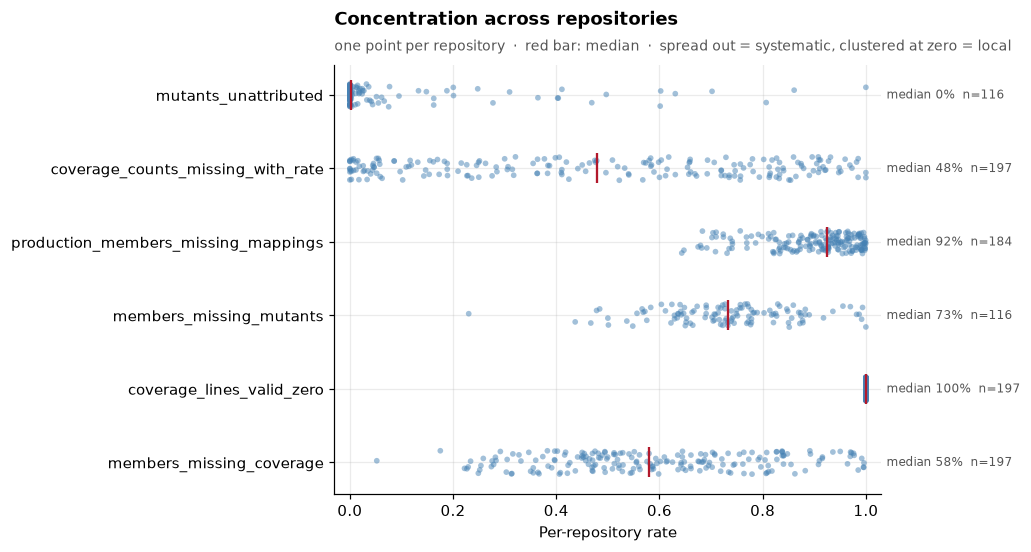

Top 5 repositories per missing-data check


,check,repo_key,numerator,denominator,rate
0,members_missing_coverage,joinrpg/joinrpg-net@075faf5460cd,8089,8119,0.9963
1,members_missing_coverage,openbullet/openbullet2@6b244ac7a584,11568,11617,0.9958
2,members_missing_coverage,eclipse-tractusx/portal-backend@fa5675c7e9d0,12732,12792,0.9953
3,members_missing_coverage,elsa-workflows/elsa-extensions@4b672e3b78a7,4454,4490,0.992
4,members_missing_coverage,avaloniaui/avalonia.samples@9e84fd03cb69,530,538,0.9851
5,members_missing_metrics,genaray/arch@4a959b8a63ed,173,1032,0.1676
6,members_missing_metrics,cysharp/zstring@e2b86f7ad433,60,661,0.09077
7,members_missing_metrics,mewssystems/funcsharp@cfca5628bfe0,296,3996,0.07407
8,members_missing_metrics,jamesmh/coravel@4072e041820f,43,937,0.04589
9,members_missing_metrics,genaray/arch.extended@18d1e4c1faec,35,794,0.04408


Top 5 repositories per defect check


,check,repo_key,numerator,denominator,rate
0,mappings_duplicate_pair,theolivenbaum/electron-sharp@2c0b299de26d,2,5,0.4
1,mappings_duplicate_pair,icsharpcode/ilspy-vscode@62b5908b16ae,60,251,0.239
2,mappings_duplicate_pair,coolnether123/rimworldmultiplayer@1e057df6d296,2,34,0.05882
3,mappings_duplicate_pair,c7-game/openciv3@d1d59861971d,15,278,0.05396
4,mappings_duplicate_pair,ppy/osu-server-spectator@e769ddd6021a,71,1768,0.04016
5,mutants_containment_violation,nbuilder/nbuilder@2769d20e112b,513,2061,0.2489
6,mutants_containment_violation,notion-dotnet/notion-sdk-net@6e82f3016dc4,155,716,0.2165
7,mutants_containment_violation,tintoy/dotnet-kube-client@6dccfe7e6733,1459,7210,0.2024
8,mutants_containment_violation,stoiveyp/slack.netstandard@815f2b3b4e41,491,2976,0.165
9,mutants_containment_violation,betalgo/openai@7c4859e368a2,332,2228,0.149


,repos_affected,total,max_repo_rate
check,,,
members_missing_coverage,197,326226,0.9963
coverage_lines_valid_zero,197,245806,1
members_missing_mutants,116,211988,1
production_members_missing_mappings,184,174931,0.9997
coverage_counts_missing_with_rate,190,113541,1
mutants_unattributed,63,99518,1
test_results_unattributed,78,62991,1
objects_missing_coverage,197,45313,0.9922
test_members_missing_mappings,158,21695,0.996


In [11]:
def check_by_repo(check_name: str, top_n: int = 15) -> pd.DataFrame:
    rows = worst_repositories(checks, check_name, top_n=top_n)
    if rows.empty:
        print(f"[none] {check_name}")
    return rows

top_checks = (
    checks[checks["numerator"] > 0]
    .groupby("check")["numerator"].sum()
    .nlargest(6).index.tolist()
)
msr_plots.per_repo_rate_strip(checks, top_checks)
plt.tight_layout()
plt.show()

# Which repositories carry each gap. Ranked per check so a bad repository is
# named rather than left inside a pooled rate; ties on rate break on volume.
TOP_N = 5

def rank_repositories(severity: str, top_n: int = TOP_N) -> pd.DataFrame:
    subset = checks[(checks["severity"] == severity) & (checks["numerator"] > 0)]
    if subset.empty:
        return pd.DataFrame()
    return (
        subset.sort_values(["check", "rate", "numerator"], ascending=[True, False, False])
        .groupby("check", group_keys=False)
        .head(top_n)
        .loc[:, ["check", "repo_key", "numerator", "denominator", "rate"]]
        .reset_index(drop=True)
    )

print(f"Top {TOP_N} repositories per missing-data check")
display(rank_repositories("coverage_gap"))

print(f"Top {TOP_N} repositories per defect check")
display(rank_repositories("defect"))

affected = (
    checks[checks["numerator"] > 0]
    .groupby("check")
    .agg(repos_affected=("repo_key", "nunique"),
         total=("numerator", "sum"),
         max_repo_rate=("rate", "max"))
    .sort_values("total", ascending=False)
)
affected

## Code Metrics

TestMap collects code metrics through a custom library built on the Roslyn API,
persisted to `code_metrics` with an `entity_type` of `member` or `object`.

Aggregates are split by entity type: a class and a method are not the same
measurement, and pooling them makes both distributions unreadable.

In [12]:
# Shared for the four construct sections below.
#   attribution_summary - how many observations resolve to a code entity
#   rank_unattributed   - which repositories carry the failures
TOP_N_REPOS = 10

def attribution_summary(check_name: str, construct: str) -> pd.DataFrame:
    rows = checks[checks["check"] == check_name]
    if rows.empty:
        return pd.DataFrame()
    missing = int(rows["numerator"].sum())
    total = int(rows["denominator"].sum())
    return pd.DataFrame([{
        "construct": construct,
        "observations": total,
        "attributed": total - missing,
        "missing_attribution": missing,
        "attributed_pct": (total - missing) / total if total else float("nan"),
    }])

def entity_gap_summary(check_name: str, entity: str) -> pd.DataFrame:
    # The complement of attribution: attribution asks whether an emitted row
    # points at a real entity, this asks how many entities never got a row.
    rows = checks[checks["check"] == check_name]
    if rows.empty:
        return pd.DataFrame()
    missing = int(rows["numerator"].sum())
    total = int(rows["denominator"].sum())
    return pd.DataFrame([{
        "entity": entity,
        "entities": total,
        "with_row": total - missing,
        "no_row": missing,
        "with_row_pct": (total - missing) / total if total else float("nan"),
        "repositories_affected": int((rows["numerator"] > 0).sum()),
    }])


def rank_unattributed(check_name: str, top_n: int = TOP_N_REPOS) -> pd.DataFrame:
    rows = checks[(checks["check"] == check_name) & (checks["numerator"] > 0)]
    if rows.empty:
        print(f"[none] no repository fired {check_name}")
        return pd.DataFrame()
    return (
        rows.sort_values(["rate", "numerator"], ascending=False)
        .head(top_n)
        .loc[:, ["repo_key", "numerator", "denominator", "rate"]]
        .reset_index(drop=True)
    )

=== code_metrics / member (532,433 rows) ===


,column,count,missing,min,max,mean,median,std
0,maintainability_index,532433,0,0,100,87.21,93,14.75
1,cyclomatic_complexity,532433,0,0,895,1.519,1,3.387
2,class_coupling,532433,0,0,250,3.295,2,4.111
3,depth_of_inheritance,532433,0,0,0,0,0,0
4,source_lines_of_code,532433,0,1,10424,8.965,4,26.8
5,executable_lines_of_code,532433,0,0,2447,3.513,2,8.615


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,maintainability_index,532433,77,93,100,23,42.5,134.5,2263,0,0.00425
1,cyclomatic_complexity,532433,1,1,2,1,-0.5,3.5,0,31586,0.05932
2,class_coupling,532433,1,2,4,3,-3.5,8.5,0,49534,0.09303
3,depth_of_inheritance,532433,0,0,0,0,0,0,0,0,0
4,source_lines_of_code,532433,1,4,10,9,-12.5,23.5,0,43740,0.08215
5,executable_lines_of_code,532433,1,2,4,3,-3.5,8.5,0,54287,0.102


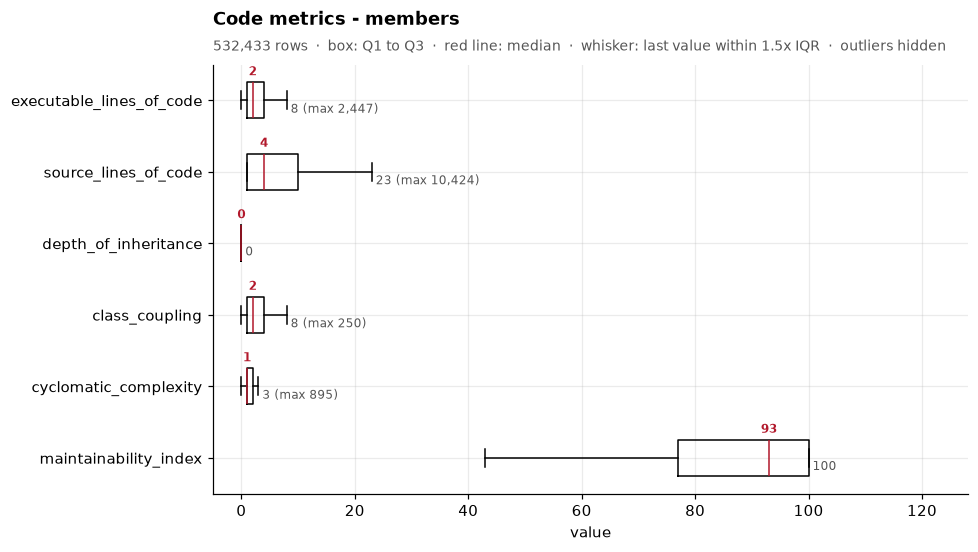

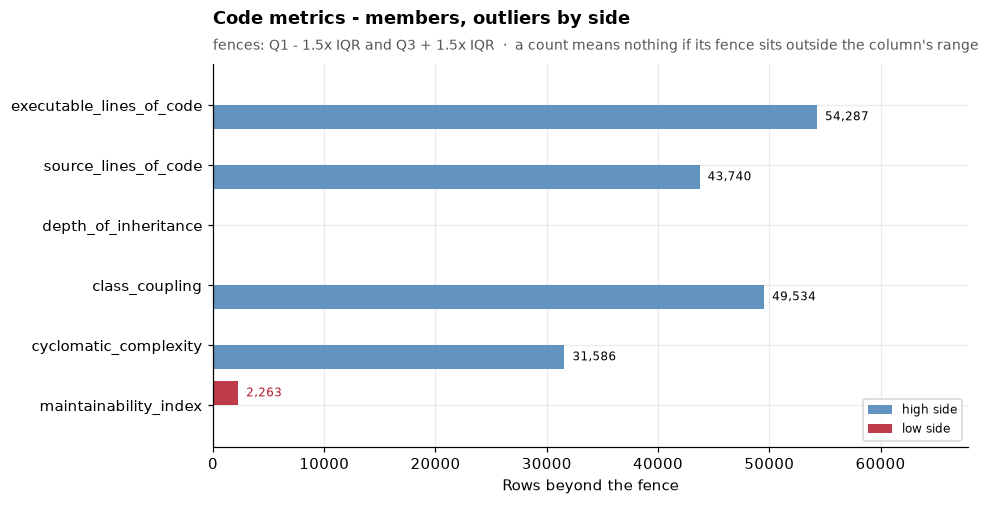

=== code_metrics / object (82,351 rows) ===


,column,count,missing,min,max,mean,median,std
0,maintainability_index,82351,0,0,100,83.51,85,14.04
1,cyclomatic_complexity,82351,0,0,2190,10.53,4,29.45
2,class_coupling,82351,0,0,1191,8.191,5,12.4
3,depth_of_inheritance,82351,0,0,10,1.266,1,0.8478
4,source_lines_of_code,82351,0,1,20207,80.67,24,313.9
5,executable_lines_of_code,82351,0,0,14523,25.7,6,105.1


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,maintainability_index,82351,73,85,97,24,37,133,261,0,0.003169
1,cyclomatic_complexity,82351,2,4,10,8,-10,22,0,8083,0.09815
2,class_coupling,82351,2,5,10,8,-10,22,0,5753,0.06986
3,depth_of_inheritance,82351,1,1,1,0,1,1,6070,18459,0.2979
4,source_lines_of_code,82351,10,24,64,54,-71,145,0,9537,0.1158
5,executable_lines_of_code,82351,2,6,20,18,-25,47,0,9519,0.1156


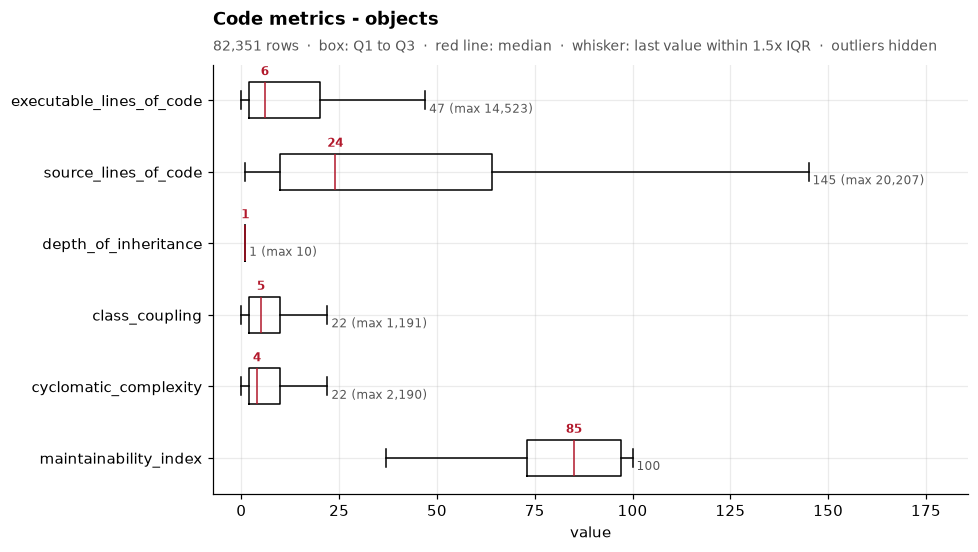

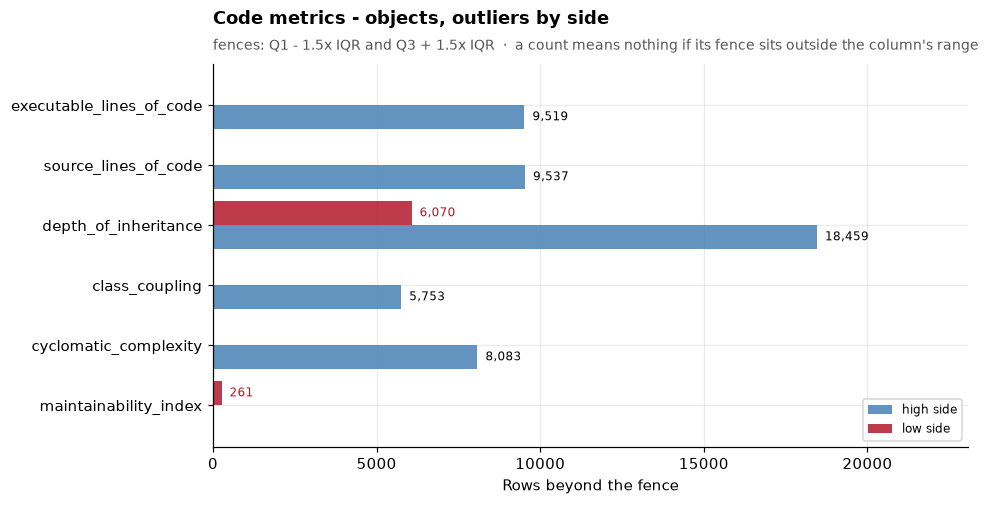

In [13]:
METRIC_COLS = NUMERIC_COLUMNS["code_metrics"]

for kind in ["member", "object"]:
    subset = code_metrics[code_metrics["entity_kind"] == kind]
    if subset.empty:
        continue
    print(f"=== code_metrics / {kind} ({len(subset):,} rows) ===")
    display(describe_numeric(subset, METRIC_COLS))
    display(iqr_table(subset, METRIC_COLS))
    msr_plots.distribution_box(subset, METRIC_COLS,
                               title=f"Code metrics - {kind}s")
    plt.tight_layout()
    plt.show()
    msr_plots.outlier_bar(iqr_table(subset, METRIC_COLS),
                          title=f"Code metrics - {kind}s, outliers by side")
    plt.tight_layout()
    plt.show()

In [14]:
# Attribution: a metric row points at an entity_id that must exist. Missing
# attribution here means the row survived but its entity did not.
#
# Same caveat as coverage below: this detects dangling references, not entries the
# mapper skipped. Members that never received a metric row are the complementary
# measure, ranked second.
display(attribution_summary("metrics_orphan_entity", "code_metrics"))
print("repositories ranked by metric rows pointing at a missing entity")
display(rank_unattributed("metrics_orphan_entity"))

# The complement, for both entity kinds: how many members and objects never
# received a metric row at all.
print("entities carrying no metric row")
display(pd.concat([
    entity_gap_summary("members_missing_metrics", "member"),
    entity_gap_summary("objects_missing_metrics", "object"),
], ignore_index=True))

print("repositories ranked by members carrying no metric row")
display(rank_unattributed("members_missing_metrics"))
print("repositories ranked by objects carrying no metric row")
display(rank_unattributed("objects_missing_metrics"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,code_metrics,614784,614784,0,1


repositories ranked by metric rows pointing at a missing entity
[none] no repository fired metrics_orphan_entity


""


entities carrying no metric row


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,member,534364,532433,1931,0.9964,84
1,object,82354,82351,3,1,2


repositories ranked by members carrying no metric row


,repo_key,numerator,denominator,rate
0,genaray/arch@4a959b8a63ed,173,1032,0.1676
1,cysharp/zstring@e2b86f7ad433,60,661,0.09077
2,mewssystems/funcsharp@cfca5628bfe0,296,3996,0.07407
3,jamesmh/coravel@4072e041820f,43,937,0.04589
4,genaray/arch.extended@18d1e4c1faec,35,794,0.04408
5,apache/casbin-casbin.net@eeb44055b7e3,74,1836,0.04031
6,mapstermapper/mapster@cbc1e5f04e6e,107,3538,0.03024
7,m-files/vaf.extensions.community@df473237c129,48,1886,0.02545
8,tyrrrz/lightbulb@95af6760fe68,10,499,0.02004
9,paillave/etl.net@21c3a6d9518d,105,5247,0.02001


repositories ranked by objects carrying no metric row


,repo_key,numerator,denominator,rate
0,dotnetcore/smartsql@8234b0a9408f,2,875,0.002286
1,hypar-io/elements@d4e7a95266e6,1,624,0.001603


## Test Smells

Smells come from an xNose-based detector. `TestSmellService` attributes each finding
to a member by file path plus nearest start line, breaking ties on the newest member
id — so stale member rows left by earlier generated attempts can win, and that is the
risk stratum for the manual attribution sheet.

The aggregate is per smell type, measured as findings per repository: the corpus
total says which smells are common, the spread says whether that is a few
repositories or all of them.

,smell_name,column,count,missing,min,max,mean,median,std
0,Assertion Roulette Test Smell,findings,149,0,1,960,83.48,38,137.4
1,Bool In Assert Equal Test Smell,findings,10,0,1,7,3.4,2,2.633
2,Conditional Test Smell,findings,164,0,1,171,21.77,9,31.36
3,Cyclomatic Complexity Test Smell,findings,18,0,1,5,1.722,1,1.074
4,Duplicate Assertion Test Smell,findings,192,0,1,1147,103.9,52,152.3
5,Eager Test Smell,findings,192,0,1,2539,196.6,93.5,331.5
6,Empty Test Smell,findings,20,0,1,11,2.35,1,2.641
7,Equal In Assert Test Smell,findings,63,0,1,55,7.952,4,9.582
8,Expected Exception Test Smell,findings,9,0,1,196,41.44,6,65.03
9,Ignored Test Smell,findings,51,0,1,46,5.078,2,8.087


,smell_name,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,Assertion Roulette Test Smell,findings,149,12,38,96,84,-114,222,0,14,0.09396
1,Bool In Assert Equal Test Smell,findings,10,1.25,2,6.25,5,-6.25,13.75,0,0,0
2,Conditional Test Smell,findings,164,3,9,27.25,24.25,-33.38,63.62,0,14,0.08537
3,Cyclomatic Complexity Test Smell,findings,18,1,1,2,1,-0.5,3.5,0,1,0.05556
4,Duplicate Assertion Test Smell,findings,192,20,52,107.5,87.5,-111.2,238.8,0,22,0.1146
5,Eager Test Smell,findings,192,40.25,93.5,198.2,158,-196.8,435.2,0,17,0.08854
6,Empty Test Smell,findings,20,1,1,2.25,1.25,-0.875,4.125,0,2,0.1
7,Equal In Assert Test Smell,findings,63,2,4,10,8,-10,22,0,5,0.07937
8,Expected Exception Test Smell,findings,9,1,6,48,47,-69.5,118.5,0,1,0.1111
9,Ignored Test Smell,findings,51,1,2,5,4,-5,11,0,5,0.09804


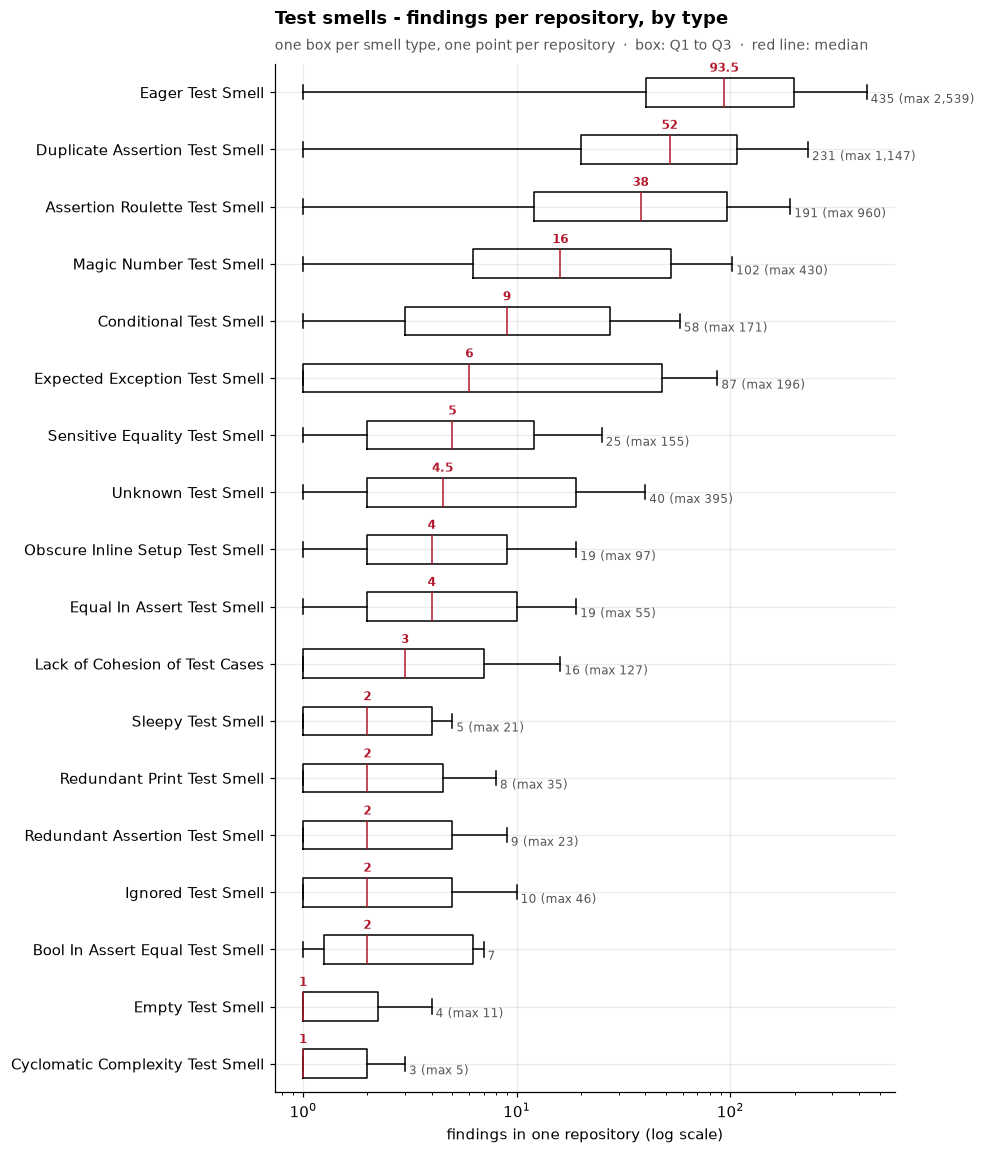

In [15]:
if not test_smells.empty:
    per_repo_type = (
        test_smells.groupby(["repo_key", "smell_name"])
        .size().rename("findings").reset_index()
    )
    display(describe_numeric(per_repo_type, ["findings"], by="smell_name"))
    display(iqr_table(per_repo_type, ["findings"], by="smell_name"))
    msr_plots.grouped_box(per_repo_type, "findings", "smell_name",
                          title="Test smells - findings per repository, by type",
                          subtitle="one box per smell type, one point per repository  ·  "
                                   "box: Q1 to Q3  ·  red line: median",
                          xlabel="findings in one repository")
    plt.tight_layout()
    plt.show()

,findings,share_of_all,repositories
smell_name,,,
Eager Test Smell,37755,0.4238,192
Duplicate Assertion Test Smell,19954,0.224,192
Assertion Roulette Test Smell,12439,0.1396,149
Magic Number Test Smell,7579,0.08508,158
Conditional Test Smell,3571,0.04009,164
Unknown Test Smell,2850,0.03199,126
Sensitive Equality Test Smell,1347,0.01512,101
Lack of Cohesion of Test Cases,970,0.01089,139
Obscure Inline Setup Test Smell,893,0.01002,101


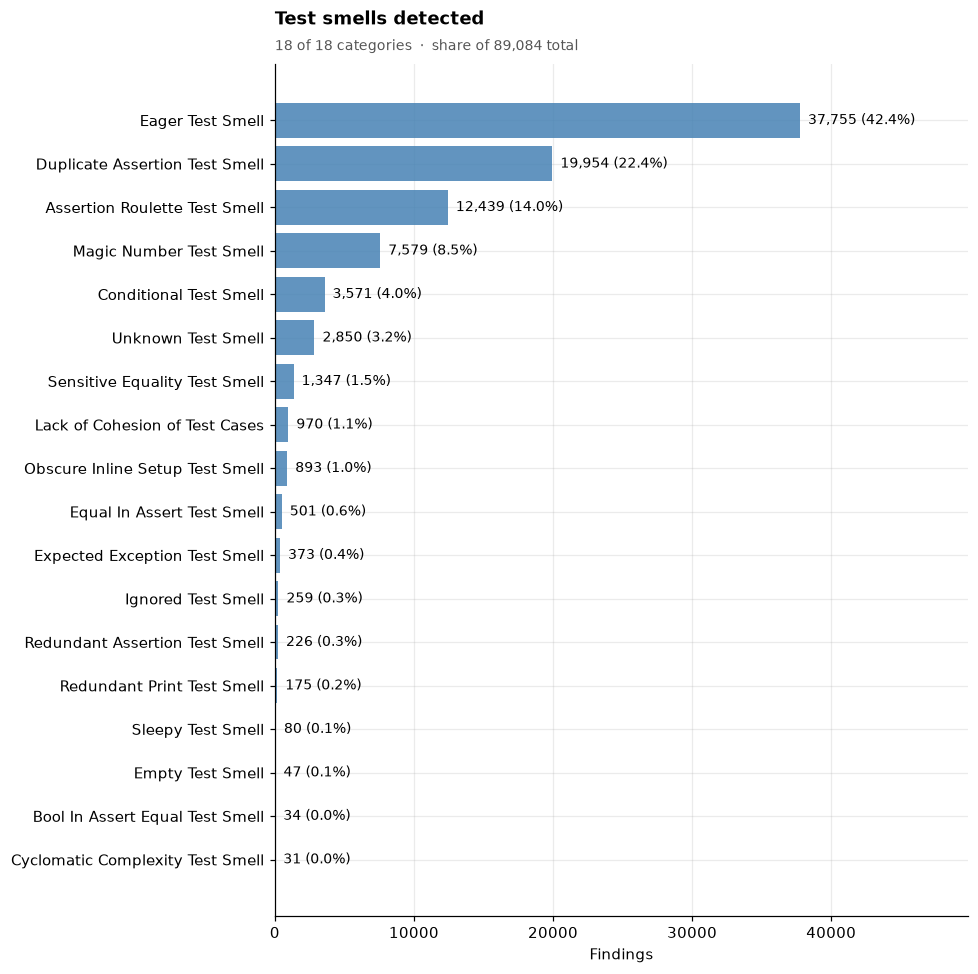

In [16]:
# Distribution across types: what share of all findings each smell accounts for.
if not test_smells.empty:
    smell_dist = (
        test_smells["smell_name"].value_counts().rename("findings").to_frame()
        .assign(share_of_all=lambda d: d["findings"] / d["findings"].sum(),
                repositories=lambda d: test_smells.groupby("smell_name")["repo_key"]
                                                  .nunique().reindex(d.index))
    )
    display(smell_dist)
    msr_plots.category_bar(test_smells["smell_name"].value_counts(),
                           "Test smells detected", "Findings", top_n=25)
    plt.tight_layout()
    plt.show()

In [17]:
# Attribution: member_id and object_id are both nullable, so a finding can land
# on no entity at all.
display(attribution_summary("smells_unattributed", "test_smells"))
print("repositories ranked by unattributed smell rate")
display(rank_unattributed("smells_unattributed"))

# The entity side of the same question. Read this one as prevalence, not as a
# gap: a test method with no smell is a clean test method, so `no_row` here is a
# property of the corpus rather than a failure of the detector. It is reported so
# every construct has both a linkage and an attribution figure.
print("test members carrying at least one smell")
display(entity_gap_summary("test_members_missing_smells", "test member"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,test_smells,89084,86758,2326,0.9739


repositories ranked by unattributed smell rate


,repo_key,numerator,denominator,rate
0,particular/particular.analyzers@d991860eed22,1,3,0.3333
1,tryagi/langchain@26bb1d16d614,45,169,0.2663
2,digitalruby/ipban@55be9aae8d12,261,990,0.2636
3,nodatime/nodatime@d3964660c577,451,1859,0.2426
4,azure-samples/iot-edge-opc-plc@f8b07ce2b659,62,278,0.223
5,taosdata/taos-connector-dotnet@930f64a4f1bd,127,585,0.2171
6,m-files/vaf.extensions.community@df473237c129,146,827,0.1765
7,infocaster/urltracker@bad768d4465f,10,82,0.122
8,cucumber/messages@4c925b936151,2,17,0.1176
9,hypar-io/elements@d4e7a95266e6,180,1900,0.09474


test members carrying at least one smell


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,test member,69342,49629,19713,0.7157,184


## Code Coverage

Coverage is parsed from Cobertura reports produced by `dotnet test` and mapped onto
members and objects.

**The coverage report is not under validation here.** The rate is taken from the
report as recorded — this study does not re-derive it, and does not attempt to
establish whether `dotnet test` measured coverage correctly. That is the coverage
tool's business, and it is carried as a threat rather than a result. What this pass
validates for coverage is **attribution**: whether a rate that the report produced
was attached to the right member.

Only `line_rate` and `branch_rate` are described. The count columns
(`lines_covered`, `lines_valid`, and the branch equivalents) are not persisted on
per-entity rows — a bug, recorded in `../msr_validation_bugs.md` — so their
distributions would describe the bug rather than the corpus.

,column,count,missing,min,max,mean,median,std
0,line_rate,245806,0,0,1,0.4404,0,0.4844
1,branch_rate,245806,0,0,1,0.8252,1,0.3627


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,line_rate,245806,0,0,1,1,-1.5,2.5,0,0,0
1,branch_rate,245806,1,1,1,0,1,1,52551,0,0.2138


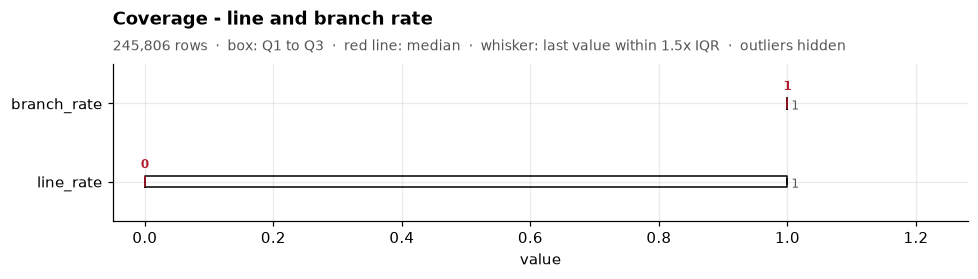

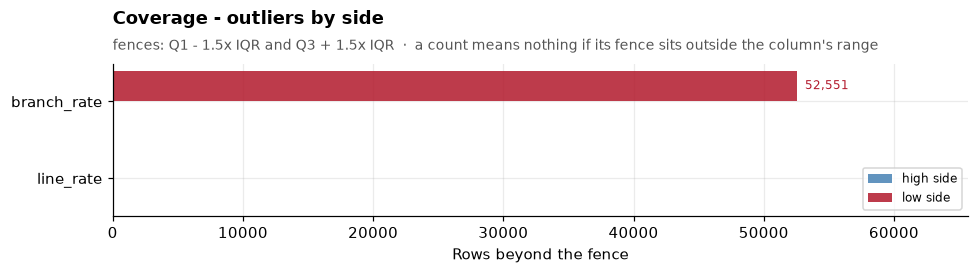

by entity type


,entity_kind,column,count,missing,min,max,mean,median,std
0,member,line_rate,208634,0,0,1,0.4385,0,0.4881
1,member,branch_rate,208634,0,0,1,0.8411,1,0.3509
2,object,line_rate,37172,0,0,1,0.4508,0.2644,0.4624
3,object,branch_rate,37172,0,0,1,0.7356,1,0.4115


,entity_kind,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,member,line_rate,208634,0,0,1,1,-1.5,2.5,0,0,0
1,member,branch_rate,208634,1,1,1,0,1,1,39724,0,0.1904
2,object,line_rate,37172,0,0.2644,1,1,-1.5,2.5,0,0,0
3,object,branch_rate,37172,0.5,1,1,0.5,-0.25,1.75,0,0,0


In [18]:
COVERAGE_COLS = ["line_rate", "branch_rate"]

if not coverage.empty:
    display(describe_numeric(coverage, COVERAGE_COLS))
    display(iqr_table(coverage, COVERAGE_COLS))
    msr_plots.distribution_box(coverage, COVERAGE_COLS, log=False,
                               title="Coverage - line and branch rate")
    plt.tight_layout()
    plt.show()
    msr_plots.outlier_bar(iqr_table(coverage, COVERAGE_COLS),
                          title="Coverage - outliers by side")
    plt.tight_layout()
    plt.show()

    print("by entity type")
    display(describe_numeric(coverage, COVERAGE_COLS, by="entity_kind"))
    display(iqr_table(coverage, COVERAGE_COLS, by="entity_kind"))

In [19]:
# Attribution, with a caveat that has to be read with the number.
#
# This measures dangling references only: does a persisted coverage row point at
# an entity that exists. It CANNOT detect a report entry the mapper failed to
# match, because that path logs a warning and skips - no row, no null, nothing in
# the database. So a 100% result here is true by construction, not evidence of a
# clean mapping. The real completeness figure comes from the run logs and is
# about 79% (see bug 6 in ../msr_validation_bugs.md).
display(attribution_summary("coverage_orphan_entity", "coverage"))
print("repositories ranked by coverage rows pointing at a missing entity")
display(rank_unattributed("coverage_orphan_entity"))

# The complementary question - members that never received a coverage row - is a
# different measurement and is dominated by projects the test run never
# instrumented, so it is ranked separately rather than folded into the rate above.
# Coverage is persisted at both grains (208,634 member rows and 37,172 object
# rows), so both grains need a linkage figure - reporting only the member side
# leaves the object rows unaccounted for.
print("entities carrying no coverage row")
display(pd.concat([
    entity_gap_summary("members_missing_coverage", "member"),
    entity_gap_summary("objects_missing_coverage", "object"),
], ignore_index=True))
print("repositories ranked by members carrying no coverage row")
display(rank_unattributed("members_missing_coverage"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,coverage,245806,245806,0,1


repositories ranked by coverage rows pointing at a missing entity
[none] no repository fired coverage_orphan_entity


""


entities carrying no coverage row


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,member,534364,208138,326226,0.3895,197
1,object,82354,37041,45313,0.4498,197


repositories ranked by members carrying no coverage row


,repo_key,numerator,denominator,rate
0,joinrpg/joinrpg-net@075faf5460cd,8089,8119,0.9963
1,openbullet/openbullet2@6b244ac7a584,11568,11617,0.9958
2,eclipse-tractusx/portal-backend@fa5675c7e9d0,12732,12792,0.9953
3,elsa-workflows/elsa-extensions@4b672e3b78a7,4454,4490,0.992
4,avaloniaui/avalonia.samples@9e84fd03cb69,530,538,0.9851
5,linkdotnet/blog@f622d4e91bd3,1162,1189,0.9773
6,jasperfx/lamar@7361b4c20cab,2822,2891,0.9761
7,tyrrrz/lightbulb@95af6760fe68,485,499,0.9719
8,encamina/enmarcha@3a1262151005,2455,2530,0.9704
9,genaray/arch.extended@18d1e4c1faec,770,794,0.9698


In [20]:
# The persistence bug, kept visible: rates without their counts.
print("coverage rows with a rate but no counts")
display(check_by_repo("coverage_counts_missing_with_rate"))
print("coverage rows where lines_valid is zero")
display(check_by_repo("coverage_lines_valid_zero"))

coverage rows with a rate but no counts


,repo_key,check,numerator,denominator,rate
0,gustavopsantos/reflex@55423389e8d4,coverage_counts_missing_with_rate,14,14,1
1,seesharper/lightinject@2fd34389552d,coverage_counts_missing_with_rate,510,510,1
2,error-or/error-or@7b18de9b9441,coverage_counts_missing_with_rate,66,67,0.9851
3,onizet/html2openxml@7380a76be250,coverage_counts_missing_with_rate,590,599,0.985
4,particular/particular.analyzers@d991860eed22,coverage_counts_missing_with_rate,327,333,0.982
5,vonage/vonage-dotnet-sdk@8cad0859af71,coverage_counts_missing_with_rate,3388,3482,0.973
6,nodatime/nodatime@d3964660c577,coverage_counts_missing_with_rate,4375,4515,0.969
7,oras-project/oras-dotnet@034b059bbbef,coverage_counts_missing_with_rate,811,845,0.9598
8,tyrrrz/cliwrap@9faa26f2a68a,coverage_counts_missing_with_rate,137,144,0.9514
9,tylerbrinks/sqlparser-cs@e1929977a962,coverage_counts_missing_with_rate,1173,1237,0.9483


coverage rows where lines_valid is zero


,repo_key,check,numerator,denominator,rate
0,a2aproject/a2a-dotnet@8fe65cfaa65a,coverage_lines_valid_zero,513,513,1
1,aalhour/c-sharp-algorithms@b82432474a91,coverage_lines_valid_zero,1262,1262,1
2,alirezanet/gridify@2d6b9b3fe66f,coverage_lines_valid_zero,1093,1093,1
3,allegro/dotnet-utils@3c8324a41ddb,coverage_lines_valid_zero,143,143,1
4,amberg/docxtemplater@35f07b7cc708,coverage_lines_valid_zero,452,452,1
5,anglesharp/anglesharp.css@346610304010,coverage_lines_valid_zero,4114,4114,1
6,apache/arrow-adbc@254ea1cfe7c6,coverage_lines_valid_zero,458,458,1
7,apache/casbin-casbin.net@eeb44055b7e3,coverage_lines_valid_zero,792,792,1
8,apache/pulsar-dotpulsar@d72d04426783,coverage_lines_valid_zero,1160,1160,1
9,arcus-azure/arcus.observability@9c12bf295de8,coverage_lines_valid_zero,300,300,1


## Mutation Score

Mutants come from Stryker.NET and are mapped to members. The consolidated frame is
aggregated per `(member, report)` with one column per mutant status — the raw
per-mutant table runs to millions of rows across the corpus, and sampling re-reads
individual mutants from the originating database.

The aggregate below is therefore per member: how many mutants one member carries,
and how they resolve. One consequence of that grain: a repository whose mutants are
*all* unattributed contributes no rows and drops out of the per-member frame
entirely, so it covers 115 repositories against the 116 that hold mutants. Mind the
denominator — the per-member frame holds only the
**572,836** mutants that attach to a member, while the operator and status tables
cover all **672,354**. The 99,518-mutant difference is exactly the unattributed
set, and it is not evenly spread: 59.5% of it is `NoCoverage`. `mutants_containment_violation` counts mutants whose reported
line falls outside the span of the member they were attributed to; where it equals
`mutants_containment_base_ambiguous`, every violation is a one-line boundary case
and the line-base convention is the thing to check, not the mapping.

,column,count,missing,min,max,mean,median,std
0,mutants_total,81646,0,1,1295,7.016,3,15.5
1,killed,81646,0,0,1292,1.306,0,6.481
2,survived,81646,0,0,607,0.9328,0,5.761
3,nocoverage,81646,0,0,1245,2.917,1,9.552
4,compileerror,81646,0,0,444,0.4637,0,3.275
5,ignored,81646,0,0,259,1.323,1,2.536
6,timeout,81646,0,0,145,0.07354,0,1.052
7,static_mutants,81646,0,0,765,0.2588,0,3.82
8,distinct_mutators,81646,0,1,21,3.038,3,2.205


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,mutants_total,81646,1,3,7,6,-8,16,0,8163,0.09998
1,killed,81646,0,0,1,1,-1.5,2.5,0,10067,0.1233
2,survived,81646,0,0,0,0,0,0,0,18812,0.2304
3,nocoverage,81646,0,1,2,2,-3,5,0,9482,0.1161
4,compileerror,81646,0,0,0,0,0,0,0,9788,0.1199
5,ignored,81646,0,1,1,1,-1.5,2.5,0,10401,0.1274
6,timeout,81646,0,0,0,0,0,0,0,2177,0.02666
7,static_mutants,81646,0,0,0,0,0,0,0,4784,0.05859
8,distinct_mutators,81646,1,3,4,3,-3.5,8.5,0,2569,0.03147


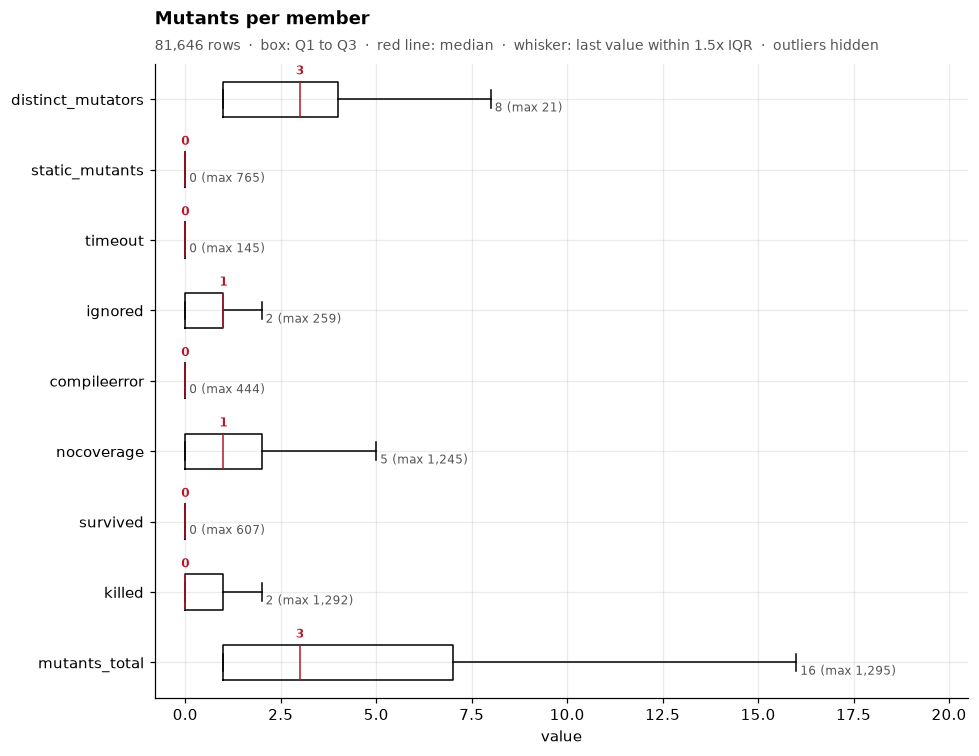

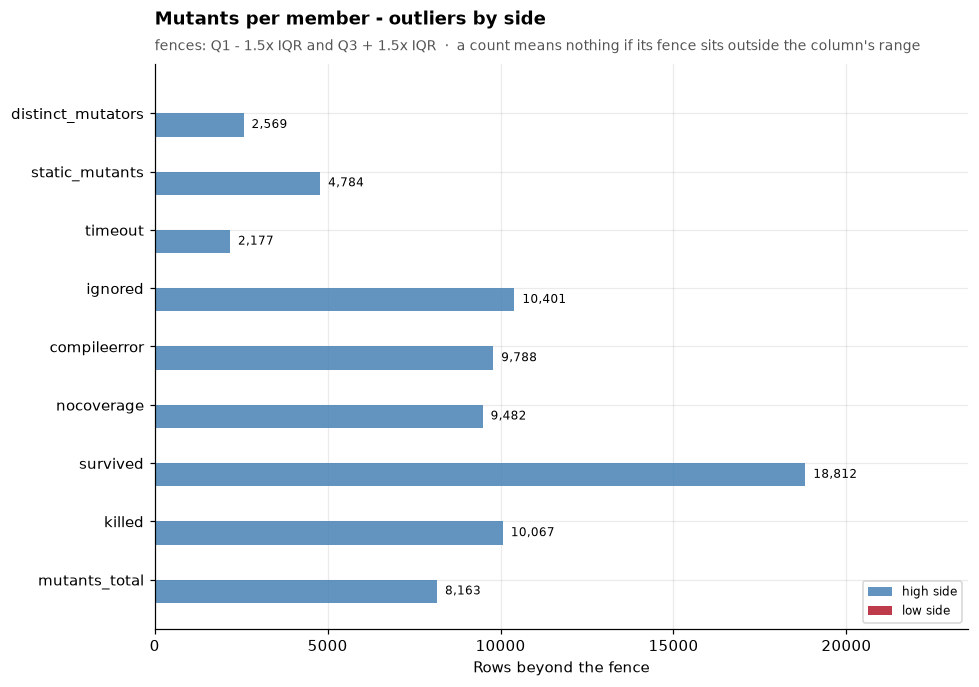

In [21]:
MUTANT_COLS = NUMERIC_COLUMNS["mutants"]

if not mutants.empty:
    display(describe_numeric(mutants, MUTANT_COLS))
    display(iqr_table(mutants, MUTANT_COLS))
    msr_plots.distribution_box(mutants, MUTANT_COLS, log=False,
                               title="Mutants per member")
    plt.tight_layout()
    plt.show()
    msr_plots.outlier_bar(iqr_table(mutants, MUTANT_COLS),
                          title="Mutants per member - outliers by side")
    plt.tight_layout()
    plt.show()

,mutants,share_of_all
status,,
NoCoverage,297427,0.4424
Ignored,126013,0.1874
Killed,117242,0.1744
Survived,80047,0.1191
CompileError,44692,0.06647
Timeout,6933,0.01031


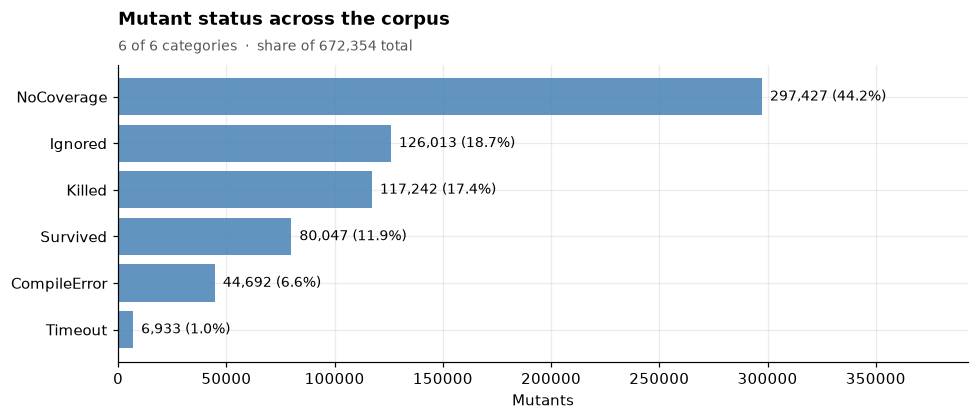

all mutants: 672,354
scored (Killed + Survived): 197,289 (29.3%)
attributed to a member: 572,836 (85.2% of all mutants)


In [22]:
# Distribution across statuses, over EVERY mutant.
#
# Two denominators exist in this section and they must not be mixed:
#   672,354  every mutant Stryker produced          (msr_mutant_operators)
#   572,836  mutants attached to a member           (msr_mutants, grouped per member)
# The difference is the 99,518 with a NULL member_id. The per-member frame cannot
# carry those - there is no member to group them under - so status shares are taken
# from the operator frame, which needs no member and therefore covers all of them.
if not mutant_operators.empty:
    status_dist = (
        mutant_operators.groupby("status")["mutants"].sum().rename("mutants").to_frame()
        .assign(share_of_all=lambda d: d["mutants"] / d["mutants"].sum())
        .sort_values("mutants", ascending=False)
    )
    display(status_dist)
    msr_plots.category_bar(status_dist["mutants"], "Mutant status across the corpus", "Mutants")
    plt.tight_layout()
    plt.show()

    total = int(status_dist["mutants"].sum())
    scored = int(status_dist.loc[["Killed", "Survived"], "mutants"].sum())
    print(f"all mutants: {total:,}")
    print(f"scored (Killed + Survived): {scored:,} ({scored / total:.1%})")

    # Same split over attributed mutants only, so the two denominators can be
    # compared rather than silently swapped between tables.
    status_cols = ["killed", "survived", "nocoverage", "compileerror", "ignored", "timeout"]
    attributed = int(mutants[status_cols].sum().sum()) if not mutants.empty else 0
    print(f"attributed to a member: {attributed:,} "
          f"({attributed / total:.1%} of all mutants)")

### Mutant status by operator

The same statuses split by which mutation operator produced the mutant. Operators
differ in how often they are killed, and in how often they are never reached at
all — a `NoCoverage` share says the operator fired in code no test touches, while a
`CompileError` share says the rewrite did not compile, which is a property of the
operator rather than of the test suite.

Stryker names Linq operators per rewrite (`Linq method mutation (Count() to Sum())`),
so the family view collapses that long tail; the exact-name table keeps it.

In [23]:
STATUS_ORDER = ["Killed", "Survived", "NoCoverage", "CompileError", "Ignored", "Timeout"]

if not mutant_operators.empty:
    by_family = (
        mutant_operators.pivot_table(index="mutator_family", columns="status",
                                     values="mutants", aggfunc="sum", fill_value=0)
        .reindex(columns=STATUS_ORDER, fill_value=0)
    )
    by_family["total"] = by_family.sum(axis=1)
    by_family["share_of_all"] = by_family["total"] / by_family["total"].sum()
    scored = by_family["Killed"] + by_family["Survived"]
    by_family["kill_rate"] = (by_family["Killed"] / scored).where(scored > 0)
    by_family = by_family.sort_values("total", ascending=False)
    display(by_family)

status,Killed,Survived,NoCoverage,CompileError,Ignored,Timeout,total,share_of_all,kill_rate
mutator_family,,,,,,,,,
Block removal mutation,9202,3456,15235,6220,123375,352,157840,0.2348,0.727
Statement mutation,21311,15166,78662,2235,714,1472,119560,0.1778,0.5842
String mutation,18867,20155,75452,2904,850,1290,119518,0.1778,0.4835
Equality mutation,23335,10860,51914,5964,257,1085,93415,0.1389,0.6824
Negate expression,10955,3601,11984,1469,68,548,28625,0.04257,0.7526
Boolean mutation,5821,5525,15074,429,395,403,27647,0.04112,0.513
Logical mutation,4506,3847,12744,2630,69,393,24189,0.03598,0.5394
Arithmetic mutation,5607,4145,10944,2234,0,272,23202,0.03451,0.575
Linq method mutation,1890,1302,1867,17147,18,87,22311,0.03318,0.5921


status,Killed,Survived,NoCoverage,CompileError,Ignored,Timeout
mutator_family,,,,,,
Bitwise mutation,0.208,0.367,0.305,0.099,0.001,0.021
LogicalNotExpression to un-LogicalNotExpression mutation,0.367,0.151,0.428,0.033,0.005,0.015
Conditional,0.317,0.245,0.321,0.08,0.015,0.021
Linq method mutation,0.085,0.058,0.084,0.769,0.001,0.004
Arithmetic mutation,0.242,0.179,0.472,0.096,0,0.012
Logical mutation,0.186,0.159,0.527,0.109,0.003,0.016
Boolean mutation,0.211,0.2,0.545,0.016,0.014,0.015
Negate expression,0.383,0.126,0.419,0.051,0.002,0.019
Equality mutation,0.25,0.116,0.556,0.064,0.003,0.012


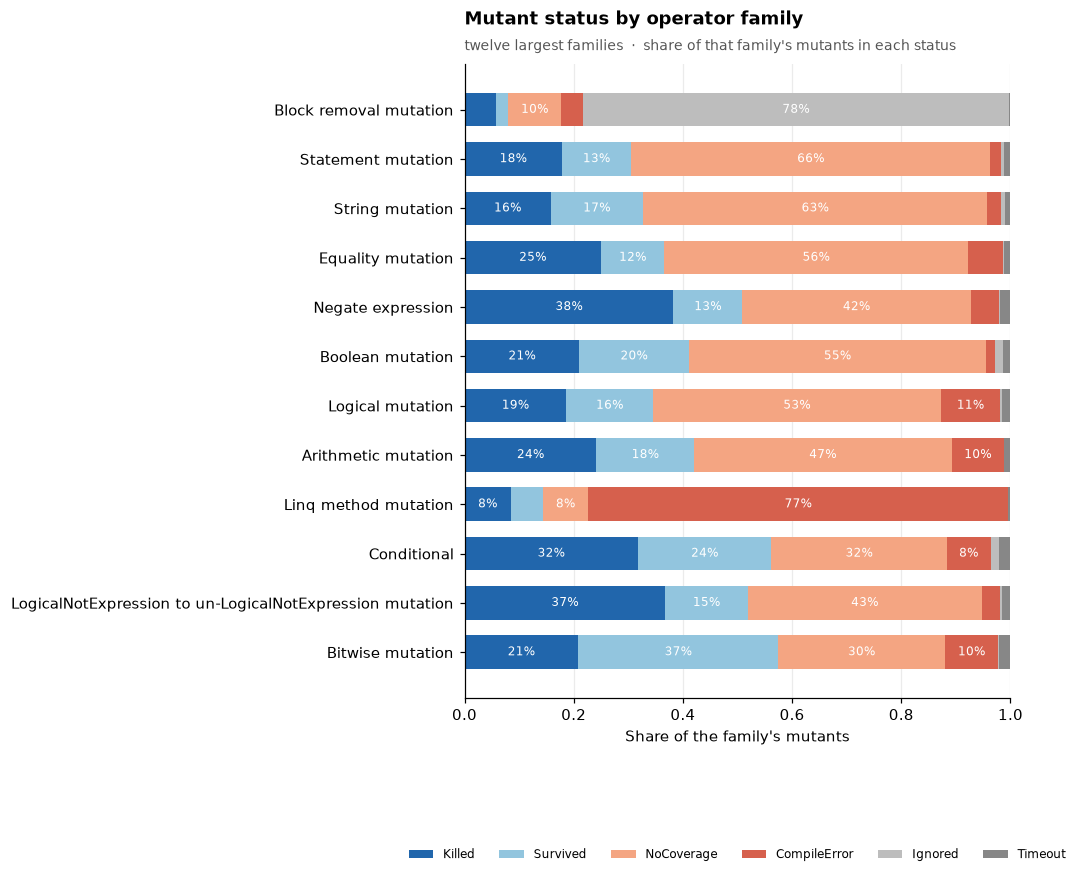

In [24]:
# Status composition per operator family, largest families first. Read down the
# NoCoverage column: an operator that mostly lands in untested code says more about
# where it fires than about the tests.
if not mutant_operators.empty:
    top_families = by_family.head(12).index
    shares = (
        by_family.loc[top_families, STATUS_ORDER]
        .pipe(lambda d: d.div(d.sum(axis=1), axis=0))
        .iloc[::-1]
    )
    display(shares.round(3))
    msr_plots.stacked_share_bar(
        shares, "Mutant status by operator family",
        subtitle="twelve largest families  ·  share of that family's mutants in each status",
        xlabel="Share of the family's mutants",
        colors=["#2166ac", "#92c5de", "#f4a582", "#d6604d", "#bdbdbd", "#878787"],
    )
    plt.tight_layout()
    plt.show()

In [25]:
# Exact operator names, for the families that hide several distinct rewrites.
if not mutant_operators.empty:
    by_name = (
        mutant_operators.pivot_table(index="mutator_name", columns="status",
                                     values="mutants", aggfunc="sum", fill_value=0)
        .reindex(columns=STATUS_ORDER, fill_value=0)
    )
    by_name["total"] = by_name.sum(axis=1)
    scored = by_name["Killed"] + by_name["Survived"]
    by_name["kill_rate"] = (by_name["Killed"] / scored).where(scored > 0)
    print(f"{len(by_name)} distinct operators")
    display(by_name.sort_values("total", ascending=False).head(25))

76 distinct operators


status,Killed,Survived,NoCoverage,CompileError,Ignored,Timeout,total,kill_rate
mutator_name,,,,,,,,
Block removal mutation,9202,3456,15235,6220,123375,352,157840,0.727
Statement mutation,21311,15166,78662,2235,714,1472,119560,0.5842
String mutation,18867,20155,75452,2904,850,1290,119518,0.4835
Equality mutation,23335,10860,51914,5964,257,1085,93415,0.6824
Negate expression,10955,3601,11984,1469,68,548,28625,0.7526
Boolean mutation,5821,5525,15074,429,395,403,27647,0.513
Logical mutation,4506,3847,12744,2630,69,393,24189,0.5394
Arithmetic mutation,5607,4145,10944,2234,0,272,23202,0.575
LogicalNotExpression to un-LogicalNotExpression mutation,3912,1610,4560,350,53,160,10645,0.7084


In [26]:
# Attribution: member_id is nullable, so Stryker can report a mutant TestMap
# cannot place on any entity.
display(attribution_summary("mutants_unattributed", "mutants"))
print("repositories ranked by unattributed mutant rate")
display(rank_unattributed("mutants_unattributed"))
print("members carrying no mutants")
display(entity_gap_summary("members_missing_mutants", "member"))
print("repositories ranked by members carrying no mutants")
display(rank_unattributed("members_missing_mutants"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,mutants,672354,572836,99518,0.852


repositories ranked by unattributed mutant rate


,repo_key,numerator,denominator,rate
0,videokojot/efcore.bulkextensions.mit@ce220063a522,9566,9566,1
1,genaray/arch@4a959b8a63ed,10301,11964,0.861
2,ardalis/guardclauses@41162c469462,284,352,0.8068
3,error-or/error-or@7b18de9b9441,259,369,0.7019
4,opentok/opentok-.net-sdk@e1fe5e665863,1214,1925,0.6306
5,luca-piccioni/opengl.net@b64077490b5d,37934,62974,0.6024
6,cysharp/zstring@e2b86f7ad433,9930,16512,0.6014
7,mattosaurus/pgpcore@d5efce26a821,1113,2240,0.4969
8,neo-project/neo-vm@99095c26663c,1068,2278,0.4688
9,mattpannella/pupdate@07452a17af89,3474,8453,0.411


members carrying no mutants


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,member,292704,80716,211988,0.2758,116


repositories ranked by members carrying no mutants


,repo_key,numerator,denominator,rate
0,videokojot/efcore.bulkextensions.mit@ce220063a522,1099,1099,1
1,handlebars-net/handlebars.net.helpers@3cc25961...,924,930,0.9935
2,shipengine/shipengine-dotnet@ff04c26f2a26,5186,5229,0.9918
3,noscoreio/noscore.packets@b759975a8cdb,5611,5685,0.987
4,simplcommerce/simplcommerce@3472ba02a6f2,3871,3942,0.982
5,tyrrrz/lightbulb@95af6760fe68,484,499,0.9699
6,yellow-dog-man/resonitelink@067afad3d197,1483,1552,0.9555
7,ruslan-b/ffmpeg.autogen@444925cd53d3,527,563,0.9361
8,ardalis/guardclauses@41162c469462,581,633,0.9179
9,qowaiv/qowaiv@8a64b2447ab3,5748,6457,0.8902


## Test Members And Execution

The test side of the corpus: how much of the mined code is test code, which
frameworks it uses, whether executed results attach to a test member, and how those
tests resolve and how long they take.

`test_results.method_id` is NOT NULL, so an unresolved test name is stored as **0**
rather than as a null. That makes this gap visible from the database — unlike the
coverage mapper, which drops unmatched entries entirely and leaves nothing to count.

Attribution is reported in both directions, because they answer different questions:
how many **results** failed to attach to a member, and how many **members** never
received a result.

In [27]:
# How much of the corpus is test code.
members_frame = entities[entities["entity_kind"] == "member"]
objects_frame = entities[entities["entity_kind"] == "object"]

test_shape = pd.DataFrame([
    {"entity": "members", "total": len(members_frame),
     "test": int(members_frame["is_test"].sum())},
    {"entity": "objects", "total": len(objects_frame),
     "test": int(objects_frame["is_test"].sum())},
]).assign(test_share=lambda d: d["test"] / d["total"],
          production=lambda d: d["total"] - d["test"])
display(test_shape)

print("test members per repository")
per_repo_tests = repositories[["repo_key", "members", "test_members"]].copy()
per_repo_tests["test_share"] = per_repo_tests["test_members"] / per_repo_tests["members"]
display(describe_numeric(per_repo_tests, ["test_members", "test_share"]))
display(iqr_table(per_repo_tests, ["test_members", "test_share"]))

,entity,total,test,test_share,production
0,members,534364,69345,0.1298,465019
1,objects,82354,9468,0.115,72886


test members per repository


,column,count,missing,min,max,mean,median,std
0,test_members,197,0,2,"3,945",352,180,547.3
1,test_share,197,0,0.0007305,0.6667,0.1456,0.1051,0.1246


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,test_members,197,86,180,392,306,-373,851,0,18,0.09137
1,test_share,197,0.05347,0.1051,0.2141,0.1607,-0.1875,0.4551,0,5,0.02538


,test_classes,share,repositories
test_framework,,,
xUnit,5132,0.542,136
NUnit,2954,0.312,130
MSTest,1382,0.146,32


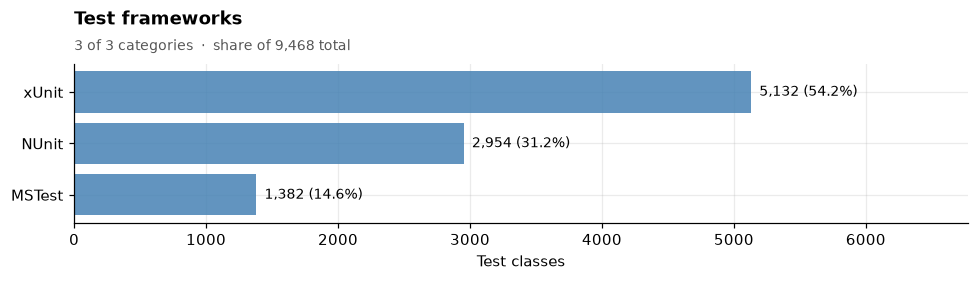

In [28]:
# Framework shares. Counted over test objects, since the framework is a property
# of the test class rather than of an individual test method.
test_objects = objects_frame[objects_frame["is_test"] == 1]
if not test_objects.empty:
    frameworks = (
        test_objects["test_framework"].fillna("(none recorded)")
        .value_counts().rename("test_classes").to_frame()
        .assign(share=lambda d: d["test_classes"] / d["test_classes"].sum(),
                repositories=lambda d: test_objects.groupby(
                    test_objects["test_framework"].fillna("(none recorded)")
                )["repo_key"].nunique().reindex(d.index))
    )
    display(frameworks)
    msr_plots.category_bar(frameworks["test_classes"],
                           "Test frameworks", "Test classes")
    plt.tight_layout()
    plt.show()

In [29]:
# Attribution: does an executed test attach to a test member?
display(attribution_summary("test_results_unattributed", "test_results"))
print("repositories ranked by unattributed test result rate")
display(rank_unattributed("test_results_unattributed"))

# The complement: test members the runner never reported a result for. These are
# different questions - a result with no member, versus a member with no result -
# and they do not have to agree.
print("test members carrying no test result")
display(entity_gap_summary("test_members_missing_results", "test member"))
print("repositories ranked by test members carrying no result")
display(rank_unattributed("test_members_missing_results"))

,construct,observations,attributed,missing_attribution,attributed_pct
0,test_results,201659,138668,62991,0.6876


repositories ranked by unattributed test result rate


,repo_key,numerator,denominator,rate
0,infocaster/urltracker@bad768d4465f,183,183,1
1,particular/particular.analyzers@d991860eed22,6052,6128,0.9876
2,nodatime/nodatime@d3964660c577,38780,41476,0.935
3,azure/template-analyzer@fd50b81c3c5a,581,734,0.7916
4,qowaiv/qowaiv@8a64b2447ab3,6717,9408,0.714
5,onizet/html2openxml@7380a76be250,484,752,0.6436
6,azure-samples/iot-edge-opc-plc@f8b07ce2b659,228,384,0.5938
7,mewssystems/funcsharp@cfca5628bfe0,486,924,0.526
8,genaray/arch@4a959b8a63ed,65,131,0.4962
9,taosdata/taos-connector-dotnet@930f64a4f1bd,273,554,0.4928


test members carrying no test result


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,test member,69345,65293,4052,0.9416,49


repositories ranked by test members carrying no result


,repo_key,numerator,denominator,rate
0,infocaster/urltracker@bad768d4465f,96,96,1
1,particular/particular.analyzers@d991860eed22,110,129,0.8527
2,digitalruby/ipban@55be9aae8d12,515,610,0.8443
3,arcus-azure/arcus.security@2303d2996825,267,324,0.8241
4,googleapis/dotnet-spanner-entity-framework@7fe...,473,876,0.54
5,nimblepros/eshoponweb@d46afba42185,46,101,0.4554
6,azure-samples/iot-edge-opc-plc@f8b07ce2b659,49,127,0.3858
7,onizet/html2openxml@7380a76be250,65,199,0.3266
8,firebend/auto-crud@c7d41f7959d6,51,170,0.3
9,testcontainers/testcontainers-dotnet@1717807affaa,100,376,0.266


,results,share_of_all
outcome,,
Passed,190541,0.9449
Failed,8897,0.04412
NotExecuted,2221,0.01101


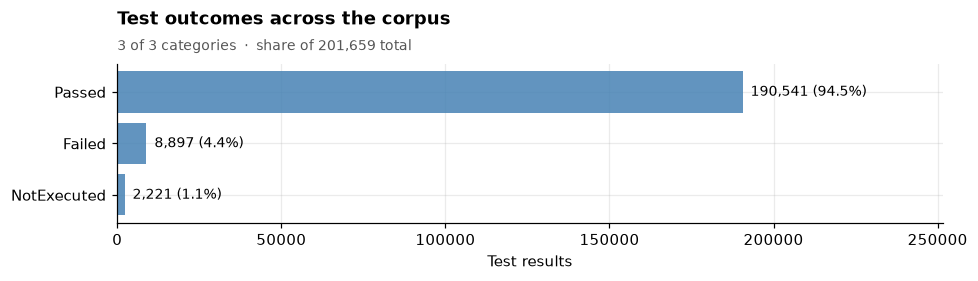

,column,count,missing,min,max,mean,median,std
0,results,197,0,2,4.148e+04,"1,024",324,"3,216"
1,pass_rate,197,0,0,1,0.8735,0.9975,0.2532


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,results,197,131,324,928,797,"-1,064","2,124",0,17,0.08629
1,pass_rate,197,0.9007,0.9975,1,0.09933,0.7517,1.149,33,0,0.1675


In [30]:
# Outcome shares across every executed test.
if not test_results.empty:
    outcome_dist = (
        test_results["outcome"].value_counts().rename("results").to_frame()
        .assign(share_of_all=lambda d: d["results"] / d["results"].sum())
    )
    display(outcome_dist)
    msr_plots.category_bar(outcome_dist["results"],
                           "Test outcomes across the corpus", "Test results")
    plt.tight_layout()
    plt.show()

    # Per repository, so a handful of huge suites cannot set the corpus rate.
    per_repo_outcome = (
        test_results.assign(passed=lambda d: d["outcome"].eq("Passed"))
        .groupby("repo_key")["passed"].agg(results="size", passed="sum")
        .assign(pass_rate=lambda d: d["passed"] / d["results"])
        .reset_index()
    )
    display(describe_numeric(per_repo_outcome, ["results", "pass_rate"]))
    display(iqr_table(per_repo_outcome, ["results", "pass_rate"]))

,column,count,missing,min,max,mean,median,std
0,duration_seconds,201659,0,0,249.3,0.1189,0.0007502,1.784


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,duration_seconds,201659,4.5e-05,0.0007502,0.006386,0.006341,-0.009467,0.0159,0,37670,0.1868


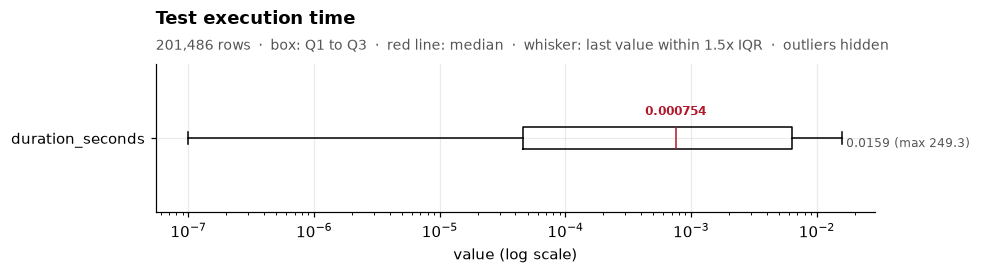

by outcome


,outcome,column,count,missing,min,max,mean,median,std
0,Failed,duration_seconds,8897,0,0,82.72,0.2059,0.001,1.408
1,NotExecuted,duration_seconds,2221,0,0,0.275,0.006879,0.001,0.01378
2,Passed,duration_seconds,190541,0,1e-07,249.3,0.1162,0.0006082,1.81


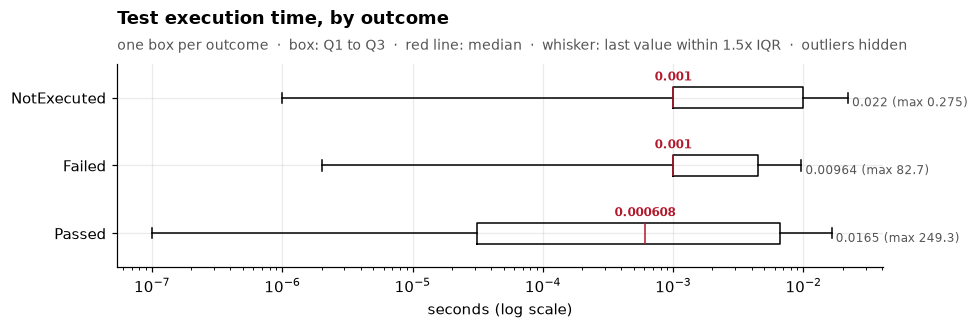

In [31]:
# Execution time. Durations are .NET TimeSpan strings converted to seconds; the
# distribution is heavy-tailed enough that the log axis is the readable one.
if not test_results.empty and test_results["duration_seconds"].notna().any():
    timed = test_results[test_results["duration_seconds"] > 0]
    display(describe_numeric(test_results, ["duration_seconds"]))
    display(iqr_table(test_results, ["duration_seconds"]))
    msr_plots.distribution_box(timed, ["duration_seconds"],
                               title="Test execution time")
    plt.tight_layout()
    plt.show()

    print("by outcome")
    display(describe_numeric(test_results, ["duration_seconds"], by="outcome"))
    msr_plots.grouped_box(timed, "duration_seconds", "outcome",
                          title="Test execution time, by outcome",
                          xlabel="seconds")
    plt.tight_layout()
    plt.show()

## Source To Test Mappings

Mappings come from Roslyn semantic traces, persisted with an evidence kind, a path
length and a chain of trace steps.

What this pass checks is shape, not correctness: that `(source_member_id,
test_member_id)` is unique, and that mappings point the right way.

The production-member denominator is scoped to **methods and constructors**.
Mapping evidence is direct method and constructor invocation, so a property or a
field can never carry a mapping — including them would put every property and field
in the denominator at a structural zero and make the rate describe the evidence
model rather than the data. The by-kind table below carries the counts.
`mappings_source_is_test_member` and `mappings_test_not_test_member` catch a source
that is itself a test method, or a test end that is not a test member. Whether a
mapping describes a test that genuinely exercises the member is a rater question,
not one the frames can answer.

In [32]:
# Both complements. A mapping has two ends, so "what has no mapping" is two
# questions: tests whose target the resolver never reached, and production code
# no test provably exercises.
print("members carrying no mapping")
display(pd.concat([
    entity_gap_summary("test_members_missing_mappings", "test member"),
    entity_gap_summary("production_members_missing_mappings", "production member"),
], ignore_index=True))

print("repositories ranked by test members carrying no mapping")
display(rank_unattributed("test_members_missing_mappings"))

# Attribution, asked the same way as for smells, mutants, and test results. Both
# endpoints are NOT NULL foreign keys, so a mapping the resolver could not
# attribute is never written at all: this row is 0 by construction and is
# evidence about the schema, not about the resolver. The resolver's misses are
# only visible from the entity side, in the two complements above.
print("mapping rows naming no entity")
display(attribution_summary("mappings_unattributed", "mappings"))

for check in ["mappings_duplicate_pair",
              "mappings_source_is_test_member", "mappings_test_not_test_member"]:
    print(check)
    display(check_by_repo(check, top_n=10))

members carrying no mapping


,entity,entities,with_row,no_row,with_row_pct,repositories_affected
0,test member,66487,44792,21695,0.6737,158
1,production member,193821,18890,174931,0.09746,184


repositories ranked by test members carrying no mapping


,repo_key,numerator,denominator,rate
0,chickensoft-games/godotenv@9a9bfdbd2511,246,247,0.996
1,microsoft/codeql@b16c2640704c,142,143,0.993
2,intellitect/codingguidelines@85a9aceb1f23,112,113,0.9912
3,siemens/ix-blazor@a18593ab52e9,339,343,0.9883
4,hypar-io/elements@d4e7a95266e6,771,782,0.9859
5,ardalis/guardclauses@41162c469462,394,400,0.985
6,allegro/dotnet-utils@3c8324a41ddb,107,109,0.9817
7,conductor-oss/csharp-sdk@632410f250be,173,177,0.9774
8,mteheran/api-colombia@db5474f55d97,179,187,0.9572
9,ltilibrary/ltiadvantage@639d11d5f022,33,35,0.9429


mapping rows naming no entity


...

,repo_key,check,numerator,denominator,rate
0,theolivenbaum/electron-sharp@2c0b299de26d,mappings_duplicate_pair,2,5,0.4
1,icsharpcode/ilspy-vscode@62b5908b16ae,mappings_duplicate_pair,60,251,0.239
2,coolnether123/rimworldmultiplayer@1e057df6d296,mappings_duplicate_pair,2,34,0.05882
3,c7-game/openciv3@d1d59861971d,mappings_duplicate_pair,15,278,0.05396
4,ppy/osu-server-spectator@e769ddd6021a,mappings_duplicate_pair,71,1768,0.04016
5,cmllib/cmllib.core@55f1cb9f3261,mappings_duplicate_pair,10,278,0.03597
6,github/gh-gei@230bba8a65f5,mappings_duplicate_pair,16,497,0.03219
7,ubisoft/ngitlab@a8fec69e9254,mappings_duplicate_pair,166,5229,0.03175
8,net-daemon/netdaemon@ca717d7aba6c,mappings_duplicate_pair,25,859,0.0291
9,yellowfeather/dbfdatareader@4f6ac3e29a65,mappings_duplicate_pair,35,1655,0.02115


mappings_source_is_test_member


,repo_key,check,numerator,denominator,rate
0,a2aproject/a2a-dotnet@8fe65cfaa65a,mappings_source_is_test_member,0,425,0
1,aalhour/c-sharp-algorithms@b82432474a91,mappings_source_is_test_member,0,211,0
2,alirezanet/gridify@2d6b9b3fe66f,mappings_source_is_test_member,0,1660,0
3,allegro/dotnet-utils@3c8324a41ddb,mappings_source_is_test_member,0,2,0
4,amberg/docxtemplater@35f07b7cc708,mappings_source_is_test_member,0,1014,0
5,anglesharp/anglesharp.css@346610304010,mappings_source_is_test_member,0,2572,0
6,apache/arrow-adbc@254ea1cfe7c6,mappings_source_is_test_member,0,465,0
7,apache/casbin-casbin.net@eeb44055b7e3,mappings_source_is_test_member,0,614,0
8,apache/pulsar-dotpulsar@d72d04426783,mappings_source_is_test_member,0,2116,0
9,arcus-azure/arcus.observability@9c12bf295de8,mappings_source_is_test_member,0,153,0


mappings_test_not_test_member


,repo_key,check,numerator,denominator,rate
0,a2aproject/a2a-dotnet@8fe65cfaa65a,mappings_test_not_test_member,0,425,0
1,aalhour/c-sharp-algorithms@b82432474a91,mappings_test_not_test_member,0,211,0
2,alirezanet/gridify@2d6b9b3fe66f,mappings_test_not_test_member,0,1660,0
3,allegro/dotnet-utils@3c8324a41ddb,mappings_test_not_test_member,0,2,0
4,amberg/docxtemplater@35f07b7cc708,mappings_test_not_test_member,0,1014,0
5,anglesharp/anglesharp.css@346610304010,mappings_test_not_test_member,0,2572,0
6,apache/arrow-adbc@254ea1cfe7c6,mappings_test_not_test_member,0,465,0
7,apache/casbin-casbin.net@eeb44055b7e3,mappings_test_not_test_member,0,614,0
8,apache/pulsar-dotpulsar@d72d04426783,mappings_test_not_test_member,0,2116,0
9,arcus-azure/arcus.observability@9c12bf295de8,mappings_test_not_test_member,0,153,0


,mappings,repos,mean_path_length
evidence_kind,,,
DirectMethodInvocation,99273,180,1
HelperMediatedPath,43146,134,2.374
DirectConstructorInvocation,16365,158,1


,column,count,missing,min,max,mean,median,std
0,path_length,158784,0,1,4,1.373,1,0.6828


,members,mapped,mapped_share
kind,,,
method,166680,16603,0.09961
property,132430,0,0
field,102540,0,0
constructor,26779,2287,0.0854
operator,1213,0,0
conversion_operator,994,0,0
event,917,0,0
static_constructor,362,0,0
destructor,54,0,0


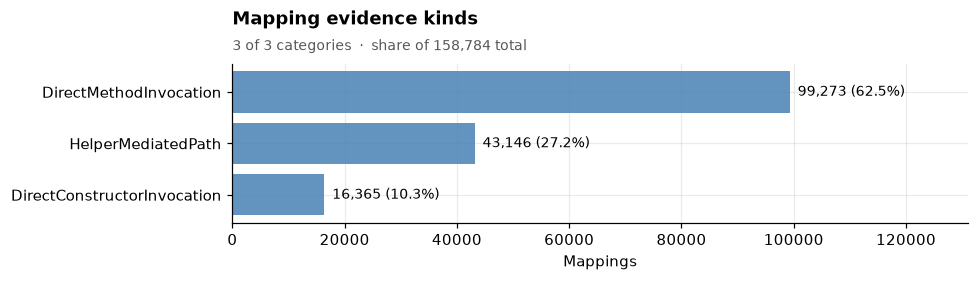

In [33]:
if not mappings.empty:
    display(
        mappings.groupby("evidence_kind")
        .agg(mappings=("observation_id", "size"),
             repos=("repo_key", "nunique"),
             mean_path_length=("path_length", "mean"))
        .sort_values("mappings", ascending=False)
    )
    display(describe_numeric(mappings, ["path_length"]))

    # Which member kinds ever receive a mapping, which is what sets the
    # denominator above.
    prod = entities[(entities["entity_kind"] == "member") & (entities["is_test"] == 0)
                    & (entities["repo_key"].isin(set(mappings["repo_key"])))]
    mapped_src = set(zip(mappings["repo_key"], mappings["source_member_id"].astype(int)))
    prod = prod.assign(has_mapping=[(r, e) in mapped_src
                                    for r, e in zip(prod["repo_key"], prod["entity_id"])])
    display(
        prod.groupby("kind")["has_mapping"]
        .agg(members="size", mapped="sum")
        .assign(mapped_share=lambda d: d["mapped"] / d["members"])
        .sort_values("members", ascending=False)
    )

    msr_plots.category_bar(mappings["evidence_kind"].value_counts(),
                           "Mapping evidence kinds", "Mappings")
    plt.tight_layout()
    plt.show()

In [34]:
# Mapping recall frame: production members with no mapping at all. This is the
# complement stratum - precision sampling cannot see it.
if not mappings.empty and not entities.empty:
    scoped = set(mappings["repo_key"])
    prod = entities[
        (entities["entity_kind"] == "member")
        & (entities["is_test"] == 0)
        & (entities["repo_key"].isin(scoped))
    ]
    mapped = set(zip(mappings["repo_key"], mappings["source_member_id"]))
    prod = prod.assign(has_mapping=[(r, e) in mapped for r, e in zip(prod["repo_key"], prod["entity_id"])])
    print(f"production members: {len(prod):,}  with a mapping: {int(prod['has_mapping'].sum()):,} "
          f"({prod['has_mapping'].mean():.1%})")
    display(
        prod.groupby("kind")["has_mapping"]
        .agg(members="size", mapped="sum")
        .assign(mapped_rate=lambda d: d["mapped"] / d["members"])
        .sort_values("members", ascending=False)
    )

production members: 431,969  with a mapping: 18,890 (4.4%)


,members,mapped,mapped_rate
kind,,,
method,166680,16603,0.09961
property,132430,0,0
field,102540,0,0
constructor,26779,2287,0.0854
operator,1213,0,0
conversion_operator,994,0,0
event,917,0,0
static_constructor,362,0,0
destructor,54,0,0


## Repository Characteristics

Descriptive statistics for the repositories themselves, so the study population can
be described rather than just counted.

Source: `Replication/LicenseFilterRepo/licenseFilteredRepoList.tsv`, the list the
target manifests were derived from (`licenseFiltered.yaml` records it as its
provenance, under its former `.csv` name). The cell takes whichever extension is
present and sniffs the delimiter, so neither the rename nor a later conversion
breaks it.

Three populations are reported side by side — the repositories **with tests
detected**, those **selected for validation**, and the **validated subset** the
frames above are built from — so the corpus can be described at whichever scope a
reader needs.

The baseline is the screening manifest
(`licenseFiltered-project-check-tests-detected-*.yaml`, 1,295 targets), not the full
1,525-repository source list. Repositories where no tests were detected never
entered the pipeline, so including them would compare the corpus against a
population it was never drawn from.

Age is measured to the manifest generation date rather than to today, so the number
does not drift every time the notebook is re-run.

In [35]:
# The file is tab-delimited and is being relabelled .tsv; take whichever exists.
import json
import re

REPO_LIST_DIR = Path("../../Replication/LicenseFilterRepo")
REPO_LIST = next(
    (REPO_LIST_DIR / f"licenseFilteredRepoList{ext}"
     for ext in (".tsv", ".csv")
     if (REPO_LIST_DIR / f"licenseFilteredRepoList{ext}").exists()),
    REPO_LIST_DIR / "licenseFilteredRepoList.tsv",
)
REFERENCE_DATE = pd.Timestamp("2026-07-16")   # licenseFiltered.yaml generated_at_utc

# Source column -> reported name. Explicit rather than fuzzy-matched: the schema
# is known, and a silent mismatch would drop a column from the table unnoticed.
REPO_COLUMNS = {
    "commits": "commits",
    "contributors": "contributors",
    "totalPullRequests": "pull_requests",
    "totalIssues": "issues",
    "size": "size_kb",
    "codeLines": "code_lines",
    "stargazers": "stars",
    "forks": "forks",
    "releases": "releases",
    "branches": "branches",
}

REPO_STAT_COLS = list(REPO_COLUMNS.values()) + ["csharp_lines", "age_years"]

if not REPO_LIST.exists():
    print(f"[missing] {REPO_LIST}")
    repo_stats = pd.DataFrame()
else:
    # The delimiter is sniffed from the header rather than assumed. This file has
    # been tab-delimited under a .csv extension; several columns carry embedded
    # JSON, so guessing wrong fails the parse outright instead of misreading.
    header = REPO_LIST.open(encoding="utf-8", errors="replace").readline()
    delimiter = "	" if header.count("	") > header.count(",") else ","
    print(f"source: {REPO_LIST.name}  ·  "
          f"delimiter: {'tab' if delimiter == chr(9) else 'comma'}")
    raw = pd.read_csv(REPO_LIST, sep=delimiter, low_memory=False)
    missing_cols = sorted(set(REPO_COLUMNS) - set(raw.columns))
    if missing_cols:
        print(f"[warn] columns not in the source list: {missing_cols}")

    repo_stats = raw.rename(columns=REPO_COLUMNS)
    created = pd.to_datetime(raw["createdAt"], errors="coerce")
    repo_stats["age_years"] = (REFERENCE_DATE - created).dt.days / 365.25
    repo_stats["repository"] = raw["name"].str.lower()

    # code_lines counts every language in the repository. Some entries are data
    # repositories with a small C# tool attached - one has 35M lines of which
    # 3,964 are C# - so the C# figure is pulled out of the per-language metrics
    # and used wherever "size" means "how much C# there is to analyse".
    def _csharp_lines(value) -> float:
        try:
            return sum(entry.get("codeLines", 0) for entry in json.loads(value)
                       if entry.get("language") == "C#")
        except (TypeError, ValueError):
            return float("nan")

    repo_stats["csharp_lines"] = raw["metrics"].map(_csharp_lines)
    share = repo_stats["csharp_lines"] / repo_stats["code_lines"]
    print(f"C# share of all code lines: median {share.median():.0%}  ·  "
          f"{int((share < 0.10).sum()):,} repositories are under 10% C#")

    print(f"{len(repo_stats):,} repositories in the full source list")

# The population that actually entered the pipeline is the screening manifest:
# repositories where a project check detected tests. Everything downstream is
# compared against that, not against the full list.
SCREENED_MANIFEST = Path(
    "../../Replication/LicenseFilterCheckProjects"
    "/licenseFiltered-project-check-tests-detected-e5cb6c9c8a53.yaml"
)

if not repo_stats.empty and SCREENED_MANIFEST.exists():
    screened_names = {
        name.lower() for name in re.findall(
            r"^ *repository: *(\S+)",
            SCREENED_MANIFEST.read_text(encoding="utf-8"), re.M)
    }
    screened = repo_stats[repo_stats["repository"].isin(screened_names)]
    print(f"{len(screened_names):,} targets in the tests-detected manifest  ·  "
          f"{len(screened):,} matched to the source list")
    screened_raw = raw[raw["name"].str.lower().isin(screened_names)]
    def _flag(column: str) -> int:
        return int(screened_raw[column].astype(str).str.upper().eq("TRUE").sum())
    print(f"forks: {_flag('isFork'):,}   archived: {_flag('isArchived'):,}")
else:
    screened = repo_stats
    if not repo_stats.empty:
        print(f"[warn] {SCREENED_MANIFEST} not found; falling back to the full list")

source: licenseFilteredRepoList.tsv  ·  delimiter: tab
C# share of all code lines: median 61%  ·  97 repositories are under 10% C#
1,525 repositories in the full source list


1,295 targets in the tests-detected manifest  ·  1,295 matched to the source list
forks: 24   archived: 8


=== repositories with tests detected (the pipeline population) ===


,column,count,missing,min,max,mean,median,std
0,commits,1295,0,204,1.451e+05,"3,532","1,135",1.044e+04
1,contributors,1295,0,10,446,57.35,29,75.64
2,pull_requests,1295,0,1,5.421e+04,"1,014",330,"3,143"
3,issues,1295,0,1,7.196e+04,728.2,192,"2,928"
4,size_kb,1295,0,272,4.983e+06,1.209e+05,1.709e+04,3.776e+05
5,code_lines,1295,0,"3,480",2.624e+07,4.182e+05,6.406e+04,1.558e+06
6,stars,1295,0,10,5.441e+04,"1,597",423,"3,736"
7,forks,1295,0,0,1.088e+04,286.9,92,662.8
8,releases,1295,0,0,"1,000",65.7,33,123.2
9,branches,1295,0,1,"1,616",45.2,14,121


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,commits,1295,554.5,"1,135","2,648","2,093","-2,585","5,787",0,140,0.1081
1,contributors,1295,17,29,60,43,-47.5,124.5,0,146,0.1127
2,pull_requests,1295,140,330,806,666,-859,"1,805",0,138,0.1066
3,issues,1295,74,192,512,438,-583,"1,169",0,146,0.1127
4,size_kb,1295,"4,133",1.709e+04,6.807e+04,6.394e+04,-9.178e+04,1.64e+05,0,179,0.1382
5,code_lines,1295,2.625e+04,6.406e+04,1.947e+05,1.685e+05,-2.265e+05,4.475e+05,0,176,0.1359
6,stars,1295,98.5,423,"1,575","1,476","-2,116","3,790",0,132,0.1019
7,forks,1295,33,92,270,237,-322.5,625.5,0,140,0.1081
8,releases,1295,7,33,73,66,-92,172,0,87,0.06718
9,branches,1295,6,14,36,30,-39,81,0,144,0.1112


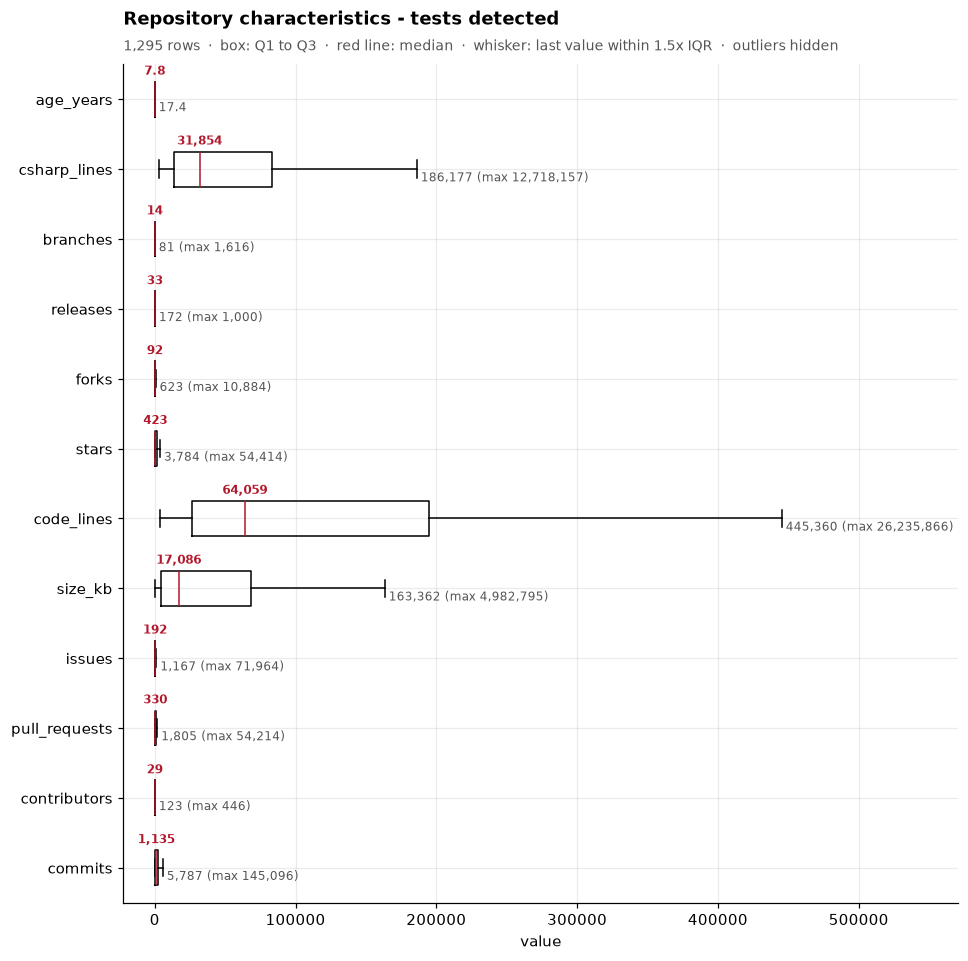

In [36]:
if not screened.empty:
    print("=== repositories with tests detected (the pipeline population) ===")
    display(describe_numeric(screened, REPO_STAT_COLS))
    display(iqr_table(screened, REPO_STAT_COLS))
    msr_plots.distribution_box(screened, REPO_STAT_COLS,
                               title="Repository characteristics - tests detected")
    plt.tight_layout()
    plt.show()

tests detected 1,295  ·  selected 346  ·  validated 197


,tests_detected,selected,validated,selected/screened,validated/selected
commits,"1,135",697.5,671,0.61,0.96
contributors,29,24,22,0.83,0.92
pull_requests,330,200.5,188,0.61,0.94
issues,192,137.5,116,0.72,0.84
size_kb,1.709e+04,"4,976","4,096",0.29,0.82
code_lines,6.406e+04,2.879e+04,2.89e+04,0.45,1
stars,423,331,348,0.78,1.05
forks,92,79.5,71,0.86,0.89
releases,33,27.5,28,0.83,1.02
branches,14,11,9,0.79,0.82


,column,count,missing,min,max,mean,median,std
0,commits,346,0,205,8.984e+04,"1,433",697.5,"4,967"
1,contributors,346,0,10,261,37.32,24,36.62
2,pull_requests,346,0,5,"9,067",422,200.5,787.3
3,issues,346,0,1,"2,519",262.4,137.5,361.4
4,size_kb,346,0,308,4.455e+05,2.27e+04,"4,976",5.123e+04
5,code_lines,346,0,"3,480",1.918e+06,6.481e+04,2.879e+04,1.415e+05
6,stars,346,0,10,1.517e+04,"1,114",331,"1,888"
7,forks,346,0,1,"1,972",188,79.5,297.2
8,releases,346,0,0,878,44.52,27.5,69.27
9,branches,346,0,1,384,21.41,11,35.17


,column,count,q1,median,q3,iqr,lower_fence,upper_fence,outliers_low,outliers_high,outlier_rate
0,commits,346,393.5,697.5,"1,385",991.2,"-1,093","2,872",0,30,0.08671
1,contributors,346,16,24,43.75,27.75,-25.62,85.38,0,29,0.08382
2,pull_requests,346,110,200.5,428.5,318.5,-367.8,906.2,0,35,0.1012
3,issues,346,63,137.5,283.8,220.8,-268.1,614.9,0,40,0.1156
4,size_kb,346,"1,817","4,976",2.08e+04,1.898e+04,-2.665e+04,4.927e+04,0,43,0.1243
5,code_lines,346,1.358e+04,2.879e+04,5.829e+04,4.472e+04,-5.35e+04,1.254e+05,0,39,0.1127
6,stars,346,87.5,331,"1,321","1,234","-1,763","3,172",0,37,0.1069
7,forks,346,31,79.5,187,156,-203,421,0,39,0.1127
8,releases,346,7,27.5,58.5,51.5,-70.25,135.8,0,19,0.05491
9,branches,346,5,11,23,18,-22,50,0,34,0.09827


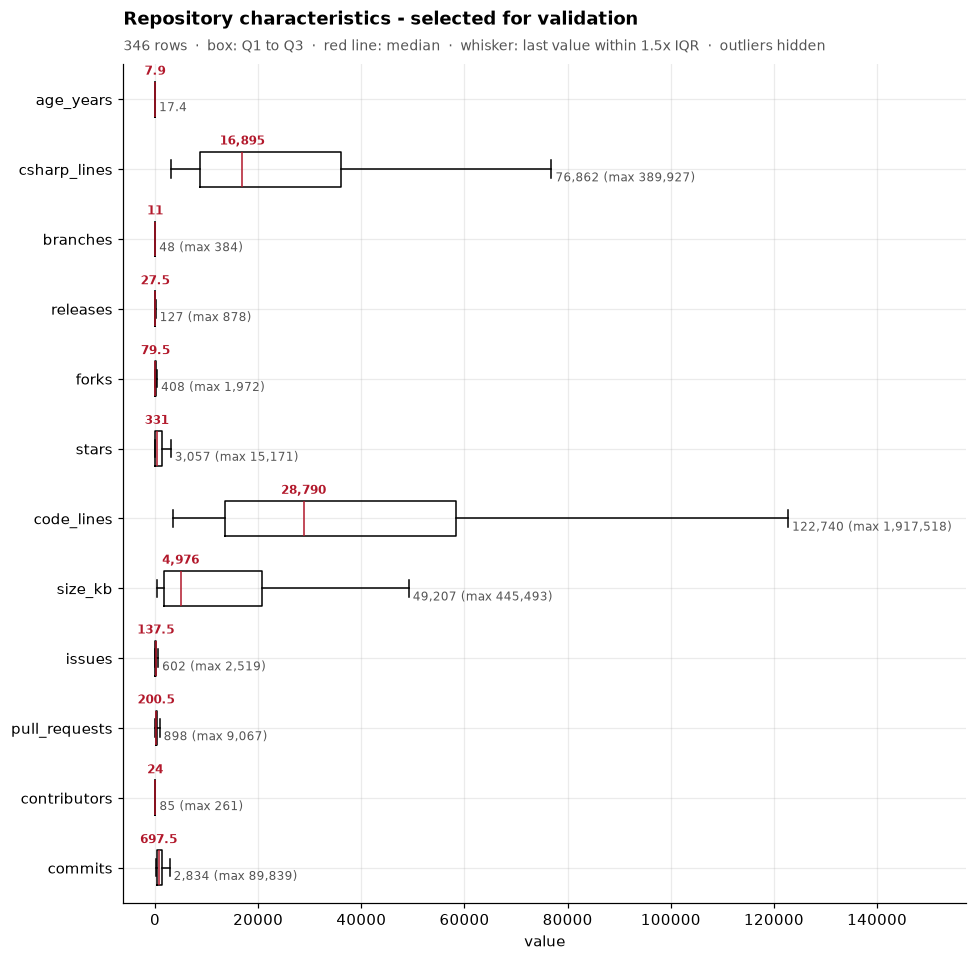

In [37]:
# Three populations side by side: the list, the repositories selected for
# validation, and the subset the frames are built from.
if not screened.empty and not repositories.empty:
    selected_names = set(population.loc[population["selected"], "repository"].str.lower())
    validated_names = set(
        (repositories["owner"].astype(str) + "/" + repositories["repo_name"].astype(str)).str.lower()
    )
    selected = screened[screened["repository"].isin(selected_names)]
    validated = screened[screened["repository"].isin(validated_names)]
    print(f"tests detected {len(screened):,}  ·  selected {len(selected):,}  ·  "
          f"validated {len(validated):,}")

    medians = pd.DataFrame({
        "tests_detected": screened[REPO_STAT_COLS].median(),
        "selected": selected[REPO_STAT_COLS].median(),
        "validated": validated[REPO_STAT_COLS].median(),
    })
    medians["selected/screened"] = (medians["selected"] / medians["tests_detected"]).round(2)
    medians["validated/selected"] = (medians["validated"] / medians["selected"]).round(2)
    display(medians)

    display(describe_numeric(selected, REPO_STAT_COLS))
    display(iqr_table(selected, REPO_STAT_COLS))
    msr_plots.distribution_box(selected, REPO_STAT_COLS,
                               title="Repository characteristics - selected for validation")
    plt.tight_layout()
    plt.show()

### Where targets leave the pipeline

Analysis cost scales with repository size, so the size of a repository and how far
it gets through the pipeline are related. Grouping targets by how much C# they
contain makes that relationship explicit, and shows which stage each group tends to
reach.

Groups are five equal-count bands, labelled with the actual line counts they span,
so a band means something concrete rather than a percentile name.

Size here is **C# lines**, not total lines. The source list's `codeLines` counts
every language, and a handful of entries are data repositories with a small C# tool
attached — the largest has 35M lines of which 3,964 are C#. Banding on the total
would put those at the top purely on the strength of their JSON.

In [38]:
if not screened.empty and not population.empty:
    joined = population.merge(
        screened[["repository", "csharp_lines", "code_lines", "size_kb",
                    "commits", "contributors"]],
        left_on=population["repository"].str.lower(), right_on="repository",
        how="left", suffixes=("", "_src"),
    )

    def pipeline_stage(row: pd.Series) -> str:
        if row["outcome"] == "timeout":
            return "timed out"
        if row["outcome"] != "completed":
            return "pipeline failed"
        if row["selected"]:
            return "selected for validation"
        return "completed, build or tests incomplete"

    STAGE_ORDER = ["selected for validation", "completed, build or tests incomplete",
                   "pipeline failed", "timed out"]
    joined["stage"] = joined.apply(pipeline_stage, axis=1)

    print("median repository, by the stage it reached")
    display(
        joined.groupby("stage")
        .agg(targets=("repository", "size"),
             csharp_lines=("csharp_lines", "median"),
             code_lines=("code_lines", "median"),
             size_kb=("size_kb", "median"),
             commits=("commits", "median"),
             contributors=("contributors", "median"))
        .reindex(STAGE_ORDER)
    )

median repository, by the stage it reached


,targets,csharp_lines,code_lines,size_kb,commits,contributors
stage,,,,,,
selected for validation,346,1.69e+04,2.879e+04,"4,976",697.5,24
"completed, build or tests incomplete",566,2.805e+04,6.088e+04,1.745e+04,"1,074",28
pipeline failed,224,5.968e+04,1.382e+05,3.11e+04,"1,648",39.5
timed out,159,1.46e+05,3.428e+05,8.172e+04,"2,972",48


stage,selected for validation,"completed, build or tests incomplete",pipeline failed,timed out
size_band,,,,
3k - 12k C# lines,116,113,26,4
12k - 22k C# lines,95,126,34,4
22k - 45k C# lines,71,133,37,18
45k - 108k C# lines,51,121,50,37
108k+ C# lines,13,73,77,96


stage,selected for validation,"completed, build or tests incomplete",pipeline failed,timed out
size_band,,,,
3k - 12k C# lines,0.448,0.436,0.1,0.015
12k - 22k C# lines,0.367,0.486,0.131,0.015
22k - 45k C# lines,0.274,0.514,0.143,0.069
45k - 108k C# lines,0.197,0.467,0.193,0.143
108k+ C# lines,0.05,0.282,0.297,0.371


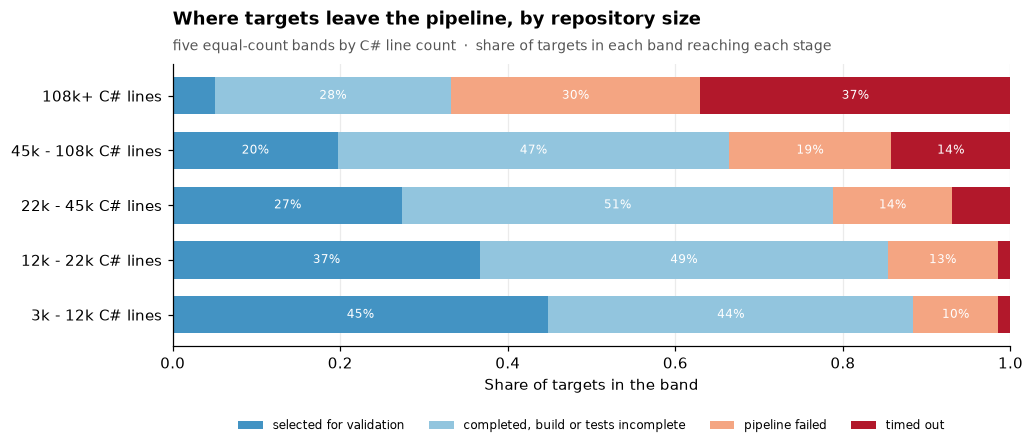

In [39]:
if not screened.empty and not population.empty and joined["csharp_lines"].notna().any():
    # Five equal-count size bands, labelled with the line counts they cover.
    bands, edges = pd.qcut(joined["csharp_lines"], 5, retbins=True, labels=False, duplicates="drop")

    def _short(value: float) -> str:
        # Scale to k or M so a boundary never reads as '12,718k'.
        if value >= 1_000_000:
            return f"{value / 1_000_000:.1f}M"
        if value >= 1_000:
            return f"{value / 1_000:,.0f}k"
        return f"{value:,.0f}"

    # The top band is open-ended: its upper edge is just the largest repository in
    # the list, which is a fact about one repository rather than a boundary.
    last = len(edges) - 2
    labels = [
        f"{_short(edges[i])}+ C# lines" if i == last
        else f"{_short(edges[i])} - {_short(edges[i + 1])} C# lines"
        for i in range(len(edges) - 1)
    ]
    joined["size_band"] = pd.Categorical(
        [labels[int(b)] if pd.notna(b) else None for b in bands],
        categories=labels, ordered=True,
    )

    counts = pd.crosstab(joined["size_band"], joined["stage"]).reindex(columns=STAGE_ORDER, fill_value=0)
    shares = counts.div(counts.sum(axis=1), axis=0)
    display(counts)
    display(shares.round(3))

    msr_plots.stacked_share_bar(
        shares, "Where targets leave the pipeline, by repository size",
        subtitle="five equal-count bands by C# line count  ·  "
                 "share of targets in each band reaching each stage",
        xlabel="Share of targets in the band",
    )
    plt.tight_layout()
    plt.show()

## What This Pass Decides

Before any sampling starts, three questions should have answers from the tables above:

1. **Which constructs are healthy enough to sample?** A construct with a systematic
   fault should be fixed first — sampling it measures the fault, not the instrument.
2. **What are the real denominators?** Availability differs sharply per construct, and
   the per-construct rater budget in the plan assumes a population that actually exists.
3. **Where do the defects concentrate?** Evenly spread means fix the extractor;
   concentrated in a few repositories means stratify the sample.

A fourth question the tables cannot answer, by design: **are the recorded values
right?** Coverage rates and mutation statuses are taken from their tools as recorded.
This pass validates that TestMap read them, kept them, and attached them to the right
code — not that `dotnet test` and Stryker measured them correctly. Tool-level
measurement error is a threat carried into the study, not a result established here.

Findings that change the plan belong in `../msr_validation_plan.md`; bugs go to
`../msr_validation_bugs.md`.

**All six bugs recorded there are to be fixed before the full evaluation run.** That
is what this pass was for: none of them has corrupted a reported result yet, and all
of them would have if the full evaluation had gone first.

One caveat carries into that work. Three of the attribution rates above read 100% —
coverage, code metrics, and source-to-test mappings — and none of them is evidence of
a clean mapping. All three drop what they cannot resolve: the coverage and metrics
mappers warn and skip, and a mapping row cannot be written at all without both member
ids, so in every case the failure never becomes a row and no database check can see
it. Measured from the run logs instead, coverage mapping drops about 21% of the
entries its reports offered. Until those failures are persisted rather than logged,
treat a clean attribution rate on those three constructs as unmeasured, not as
passing — the entity-side complements (`*_missing_*`) are where their misses show up.